## GET the data (NEW instructions July 2026 summer edition)
all in ./data directory

### -----> Cuiqi
Get the tarball containing all the data (~30GB) and place to some filesystem with enough space and not too slow
```bash
$ cd < to somewhere with more than 50GB of free space >
$ pip install magic-wormhole
$ wormhole receive < secret_code >
$ tar -xvf inp_db_STORAGE_20260710.tar.gz
```
then from within the repository, call the script to populate the `./data` directory
```bash
$ ./create_data.sh --help
$ ./create_data.sh --active-path <somewhere_with_1GB_free_space_could_be_same_FS_as_for_STORAGE> --storage-path <path_to_STORAGE_extracted_tarball>
```

### -----> Luise
You need to choose where to place the active path, where files generated by the script are stored.
for example, you can use $HPCPERM/inp_db_ACTIVE:
```bash
$ mkdir -p $HPCPERM/inp_db_ACTIVE
$ ./create_data.sh --active-path $HPCPERM/inp_db_ACTIVE --storage-path /hpcperm/papa/inp_db_STORAGE_20260710
```

## Re-organise the CSV INP DB into a class
we want something that can be used to quickly obtain the aerosols (from climatology or other datasets) at the same locations and times with some flexibilities:
* for a given set of locations, obtain aerosols for an arbitrary time range
* for a given region, extract all locations
* for a given time range, extract all locations (not yet implemented)

and so on

### Working directory
Make sure you are in the correct directory, otherwise ./data or the modules won't be found. If you are running via jupyter-lab server, you can either cd into the correct directory or manually set with `os.chdir()` from within the notebook.
```pythonimport os
os.chdir('/path/to/your/directory')
```

### For example

In [1]:
import os, sys
path_of_this_notebook = "/home/papa/Documents/explore_inp/inpdb_coloc"
os.chdir(path_of_this_notebook)

repo_root = path_of_this_notebook
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Evict any stale 'src' package cached from another project
for mod in list(sys.modules):
    if mod == "src" or mod.startswith("src."):
        del sys.modules[mod]

In [2]:
! head ./data/inp_db/20260708/INPDB_2003-2020_immersion_20260708_124249_IFS_colocation.csv

Year,Month,Day,Time,T [K],RHw [%],RHi [%],INP_amb [L-1],Lat,Lon,Alt [m],Platform,Instrument,Reference [author year],DOI,Campaign,Location,INP_stp [stdL-1]
2017.0,11.0,4.0,16:22:00,263.37,100.0,109.98,0.133075085,53.80555556,-1.555833333,100.0,Ground,Filter + uL-NIPI,Adams et al. 2020,https://doi.org/10.1029/2020JD032938,,Leeds (GB-ENG),
2017.0,11.0,4.0,16:22:00,260.45,100.0,113.17,0.269796513,53.80555556,-1.555833333,100.0,Ground,Filter + uL-NIPI,Adams et al. 2020,https://doi.org/10.1029/2020JD032938,,Leeds (GB-ENG),
2017.0,11.0,4.0,16:22:00,259.84,100.0,113.84,0.410369752,53.80555556,-1.555833333,100.0,Ground,Filter + uL-NIPI,Adams et al. 2020,https://doi.org/10.1029/2020JD032938,,Leeds (GB-ENG),
2017.0,11.0,4.0,16:22:00,259.1,100.0,114.67,0.555018139,53.80555556,-1.555833333,100.0,Ground,Filter + uL-NIPI,Adams et al. 2020,https://doi.org/10.1029/2020JD032938,,Leeds (GB-ENG),
2017.0,11.0,4.0,16:22:00,259.0,100.0,114.78,0.703985021,53.80555556,-1.555833333,100.0,Ground,Filter + uL-NIPI

## Load into collection
inp_coll stores now the content of the CSV data
cdo must be available in the current environment. If cdo is loaded as a module, do so before starting the jupyter-lab server
```bash
$ module load cdo
$ cd < to the directory of this notebook > (optional)
$ jupyter-lab < your options >
```

# Examples for using the collection API
Sorry there is nothing really documented, but I hope these examples show the available usage scenarios. Different access modes and functionalities we can implement later on. For now the model data are extracted just from the lowest available pressure level, so correct for surface. I will implement also the vertical colocation in June, but if urgent let's discuss this.

In [3]:
import os, sys

os.chdir("/home/papa/Documents/explore_inp/inpdb_coloc")

repo_root = "/home/papa/Documents/explore_inp/inpdb_coloc"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Evict any stale 'src' package cached from another project
for mod in list(sys.modules):
    if mod == "src" or mod.startswith("src."):
        del sys.modules[mod]


In [4]:
from src.config import digest_config
digest_config()

Using default value for merra2_aeronet_filelike: merra2.instM_2d_gas_Nx_AOD_MERGED_1degshifted_aeronet.nc
Using default value for macv2sp_aeronet_filelike: MACv2-SP_2Dfields_T63_1km_1980_2020_aeronet.nc
Using default value for macv2nat_aeronet_filelike: gt_n_aeronet.nc
Using default value for volcaero_file: GLOSSAC_EVA_prescribed_1980_2020_aeronetwls.nc
Using default value for lonlat_approx: 0.1
Using default value for t_approx_h: True
Using default value for cams_clim_file: aerosol_cams_climatology_49r2_1951-2019_4D.nc
Using default value for inpdb_csvfile: INPDB_2003-2020_immersion_20260708_124249_IFS_colocation.csv
Using default value for inpdb_tag: 20260708
Using default value for aeronet_freq: monthly
Using default value for aeronet_tag: 20260701
Using default value for aeronet_lev: lev20
Using default value for era5_frequency: monthly
Successfully read configuration from None


In [5]:
# There is a main class taking care of aligning and manage consistently obs and model data. It can be expanded also to include other model data, e.g. merra2 if we want (have a look at ./src/structs)

import numpy as np
import xarray as xr

from src.main import build_inp_collection
inp_coll = build_inp_collection()

Loading INP collection from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/inp_db/20260708/INPDB_2003-2020_immersion_20260708_124249_IFS_colocation.csv
Loading CAMS climatology from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/cams_clim/point_files/aerosol_cams_climatology_49r2_1951-2019_4D_inpdb_20260708.nc
Loading CAMS free output from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/cams_free/*_inpdb_20260708_zarr
Opening archives as zarr
Getting pl fields
Loading ERA5 output from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/era5/synth_files/era5_2003to2020_monthly_inpdb_20260708_zarr
Loading ERA5 geopotential output from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/era5/era5_z_inpdb_20260708.nc


In [6]:
# #co-located climatology aerosols for all entries (is the heaviest possible task, normally we would do this for a subset of observations)

# # This has vertical interpolation
# cams_clim_coloc_vert = inp_coll.get_cams_clim()
# # This colocates in space and time but takes values from fixed level.
# # Same interface also for cams_free.
# cams_clim_coloc_fixed = inp_coll.get_cams_clim(vert_interp=False, lev_idx=-1)
# import matplotlib.pyplot as plt
# var = "Mineral_Dust_bin1"
# plt.scatter(cams_clim_coloc_vert[var].values, cams_clim_coloc_fixed[var].values)
# plt.axline([0,0], slope=1, color="k", ls="--")

In [7]:
#co-located cams free aerosols for all entries (lazy loaded! to get the actual data, consider read time from disk)
inp_coll.get_cams_free()

<xarray.Dataset> Size: 20MB
Dimensions:            (obs_id: 228205)
Coordinates:
    lat                (obs_id) float64 2MB dask.array<chunksize=(1480,), meta=np.ndarray>
    lon                (obs_id) float64 2MB dask.array<chunksize=(1480,), meta=np.ndarray>
    time               (obs_id) datetime64[ns] 2MB 2003-10-05 ... 2020-09-22
  * obs_id             (obs_id) int64 2MB 0 1 2 3 ... 228202 228203 228204
Data variables:
    Sea_Salt_bin1      (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>
    Sea_Salt_bin2      (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>
    Sea_Salt_bin3      (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>
    Mineral_Dust_bin1  (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>
    Mineral_Dust_bin2  (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>
    Mineral_Dust_bin3  (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>
    t                  (obs_id) float64 2MB dask.array<chunksize=(228205,), meta=np.ndarray>

In [8]:
# All INP concentrations entries
inp_coll.INP_conc.values

array([6.28000000e+00, 9.42000000e+00, 1.57000000e+00, ...,
       3.16403342e-03, 5.00121411e-02, 2.44957426e-04], shape=(228205,))

In [9]:
# Get as Dataset
inp_coll.to_xarray()

<xarray.Dataset> Size: 11MB
Dimensions:   (obs_id: 228205)
Coordinates:
  * obs_id    (obs_id) int64 2MB 0 1 2 3 4 ... 228201 228202 228203 228204
    time      (obs_id) datetime64[ns] 2MB 2003-10-05 2003-10-05 ... 2020-09-22
    lon       (obs_id) float32 913kB 101.0 101.0 101.0 101.0 ... 78.2 78.2 78.2
    lat       (obs_id) float32 913kB 34.0 34.0 34.0 34.0 ... 86.5 86.5 86.5 86.5
    alt       (obs_id) float32 913kB 3.415e+03 3.415e+03 3.415e+03 ... 15.0 15.0
Data variables:
    RHw       (obs_id) float32 913kB 100.0 100.0 100.0 ... 100.0 100.0 100.0
    T         (obs_id) float32 913kB 253.0 248.0 258.0 ... 258.1 253.1 265.6
    RHi       (obs_id) float32 913kB 121.7 127.8 115.9 ... 115.7 121.6 107.6
    INP_conc  (obs_id) float64 2MB 6.28 9.42 1.57 ... 0.003164 0.05001 0.000245

Free lons are correct: True
Free lats are correct: True
Clim lons are correct: True
Clim lats are correct: True


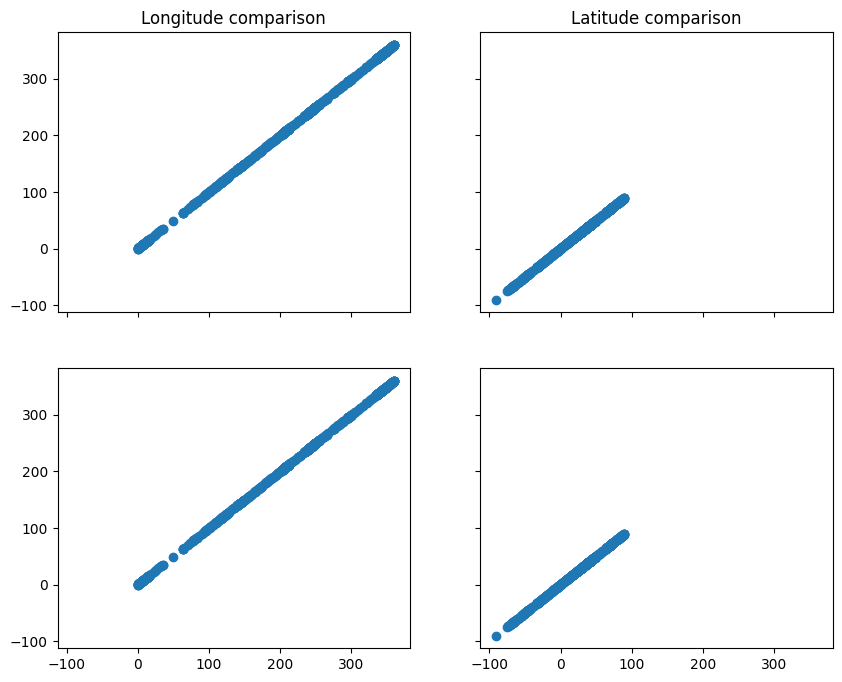

In [10]:
# Just to double-check that the coordinates between INPDB and model data are aligned
import matplotlib.pyplot as plt
fig, axs = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10, 8))
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]
ax1.scatter(inp_coll.sparse.coord_lons, inp_coll.cams_free.data.lon.values)
ax2.scatter(inp_coll.sparse.coord_lats, inp_coll.cams_free.data.lat.values)
ax3.scatter(inp_coll.sparse.coord_lons, inp_coll.cams_clim.data.lon.values)
ax4.scatter(inp_coll.sparse.coord_lats, inp_coll.cams_clim.data.lat.values)
ax1.set_title("Longitude comparison")
ax2.set_title("Latitude comparison")
print(f"Free lons are correct: {np.isclose(inp_coll.sparse.coord_lons, inp_coll.cams_free.data.lon.values).min()}")
print(f"Free lats are correct: {np.isclose(inp_coll.sparse.coord_lats, inp_coll.cams_free.data.lat.values).min()}")
print(f"Clim lons are correct: {np.isclose(inp_coll.sparse.coord_lons, inp_coll.cams_clim.data.lon.values).min()}")
print(f"Clim lats are correct: {np.isclose(inp_coll.sparse.coord_lats, inp_coll.cams_clim.data.lat.values).min()}")

For a square region, get all locations and exactly co-located aerosols from climatology

In [11]:
ini_date = "2018-01-01"
end_date = "2018-12-31"

inp_tsub = inp_coll.get_timerange_subset(ini_date, end_date)

(array([ 370., 2001., 6499.,  434.,  632.,  137., 1249.,  196.,  169.,
        1463.]),
 array([17532.        , 17566.17083333, 17600.34166667, 17634.5125    ,
        17668.68333333, 17702.85416667, 17737.025     , 17771.19583333,
        17805.36666667, 17839.5375    , 17873.70833333]),
 <BarContainer object of 10 artists>)

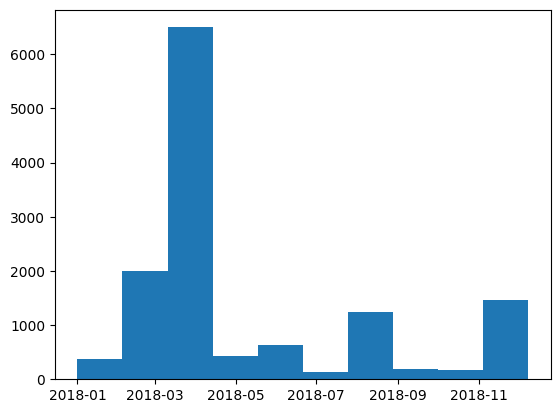

In [12]:
plt.hist(inp_tsub.time())

In [13]:
print(f"Clim lons are correct: {np.isclose(inp_tsub.sparse.coord_lons, inp_tsub.cams_clim.data.lon.values).max()}")
print(f"Clim lats are correct: {np.isclose(inp_tsub.sparse.coord_lats, inp_tsub.cams_clim.data.lat.values).max()}")
print(f"Free lons are correct: {np.isclose(inp_tsub.sparse.coord_lons, inp_tsub.cams_free.data.lon.values).max()}")
print(f"Free lats are correct: {np.isclose(inp_tsub.sparse.coord_lats, inp_tsub.cams_free.data.lat.values).max()}")

Clim lons are correct: True
Clim lats are correct: True
Free lons are correct: True
Free lats are correct: True


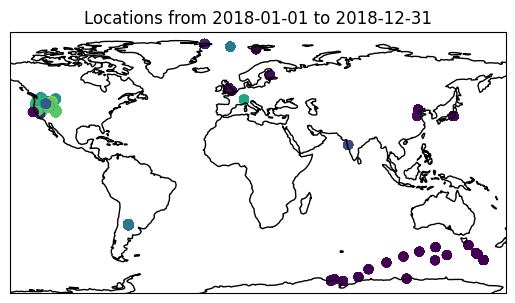

In [14]:
from cartopy import crs as ccrs
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_title(f"Locations from {ini_date} to {end_date}")
ax.scatter(inp_tsub.lon(), inp_tsub.lat(), c=inp_tsub.alt(),
            transform=ccrs.PlateCarree())

In [15]:
# Access by location
lonw, lone = 50, 170
lats, latn = -90, -40
inp_subs = inp_tsub.get_region_subset(lon_west=lonw, lon_east=lone,
                                      lat_south=lats, lat_north=latn
                                      )
sub_times = xr.DataArray(data=inp_subs.time(),
                         dims=["time"],
                         coords={"time": inp_subs.time()})

print(f"Clim lons are correct: {np.isclose(inp_subs.sparse.coord_lons, inp_subs.cams_clim.data.lon.values).max()}")
print(f"Clim lats are correct: {np.isclose(inp_subs.sparse.coord_lats, inp_subs.cams_clim.data.lat.values).max()}")
print(f"Free lons are correct: {np.isclose(inp_subs.sparse.coord_lons, inp_subs.cams_free.data.lon.values).max()}")
print(f"Free lats are correct: {np.isclose(inp_subs.sparse.coord_lats, inp_subs.cams_free.data.lat.values).max()}")

Clim lons are correct: True
Clim lats are correct: True
Free lons are correct: True
Free lats are correct: True


Text(0, 0.5, 'Latitude')

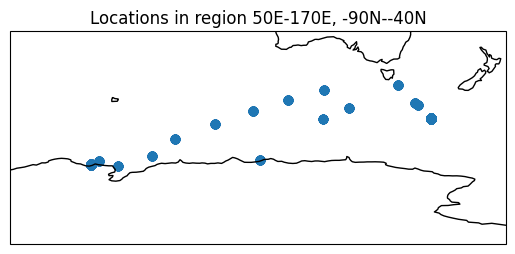

In [16]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_extent([lonw-10, lone+10, lats-10, latn+10],
              crs=ccrs.PlateCarree())
ax.set_title(f"Locations in region {lonw}E-{lone}E, {lats}N-{latn}N")
ax.scatter(inp_subs.lon(), inp_subs.lat(), transform=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [17]:
# North-western America domain
lonw, lone = 200, 300
lats, latn = 20, 70
inp_subs_nwa = inp_tsub.get_region_subset(lon_west=lonw, lon_east=lone,
                                          lat_south=lats, lat_north=latn
                                          )

Text(0, 0.5, 'Latitude')

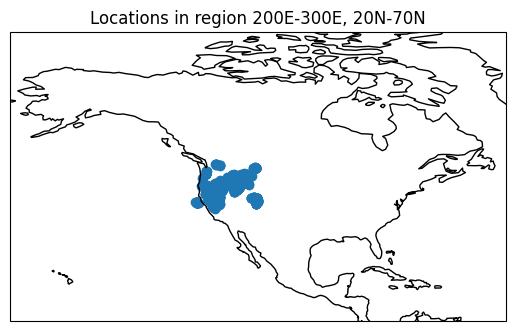

In [18]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines()
ax.set_extent([lonw-10, lone+10, lats-10, latn+10],
              crs=ccrs.PlateCarree())
ax.set_title(f"Locations in region {lonw}E-{lone}E, {lats}N-{latn}N")
ax.scatter(inp_subs_nwa.lon(), inp_subs_nwa.lat(), transform=ccrs.PlateCarree())
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

In [19]:
# Let's request all data for those dates across all locations (explode mode)
# Max temporal information from the model data
var = "Mineral_Dust_bin2"

# ranges
p1,p2 = 0.25, 0.75

# 3-hourly data throughout the covered obs period for prognostics
timerange_3h = np.arange(inp_subs.time().min(), inp_subs.time().max(), np.timedelta64(3, 'h'), dtype='datetime64')
# Daily data for the same period for climatology
timerange_d= np.arange(inp_subs.time().min(), inp_subs.time().max(), np.timedelta64(3, 'h'), dtype='datetime64')

# if lev_idx is not specified, the default is vertical co-location!
this_free_stats = inp_subs.get_cams_free(time=timerange_3h, var_subset=var).quantile([p1,0.5,p2], dim=inp_subs.obs_index_dim)
this_free_stats_ground = inp_subs.get_cams_free(time=timerange_3h, var_subset=var, lev_idx=-1).quantile([p1,0.5,p2], dim=inp_subs.obs_index_dim)
this_clim_stats = inp_subs.get_cams_clim(time=timerange_d, var_subset=var).quantile([p1,0.5,p2], dim=inp_subs.obs_index_dim)

/home/papa/_venvs/notes_py311/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


Text(0.5, 0.98, 'Range of values at each time across all locations\n Not very physical but just an example')

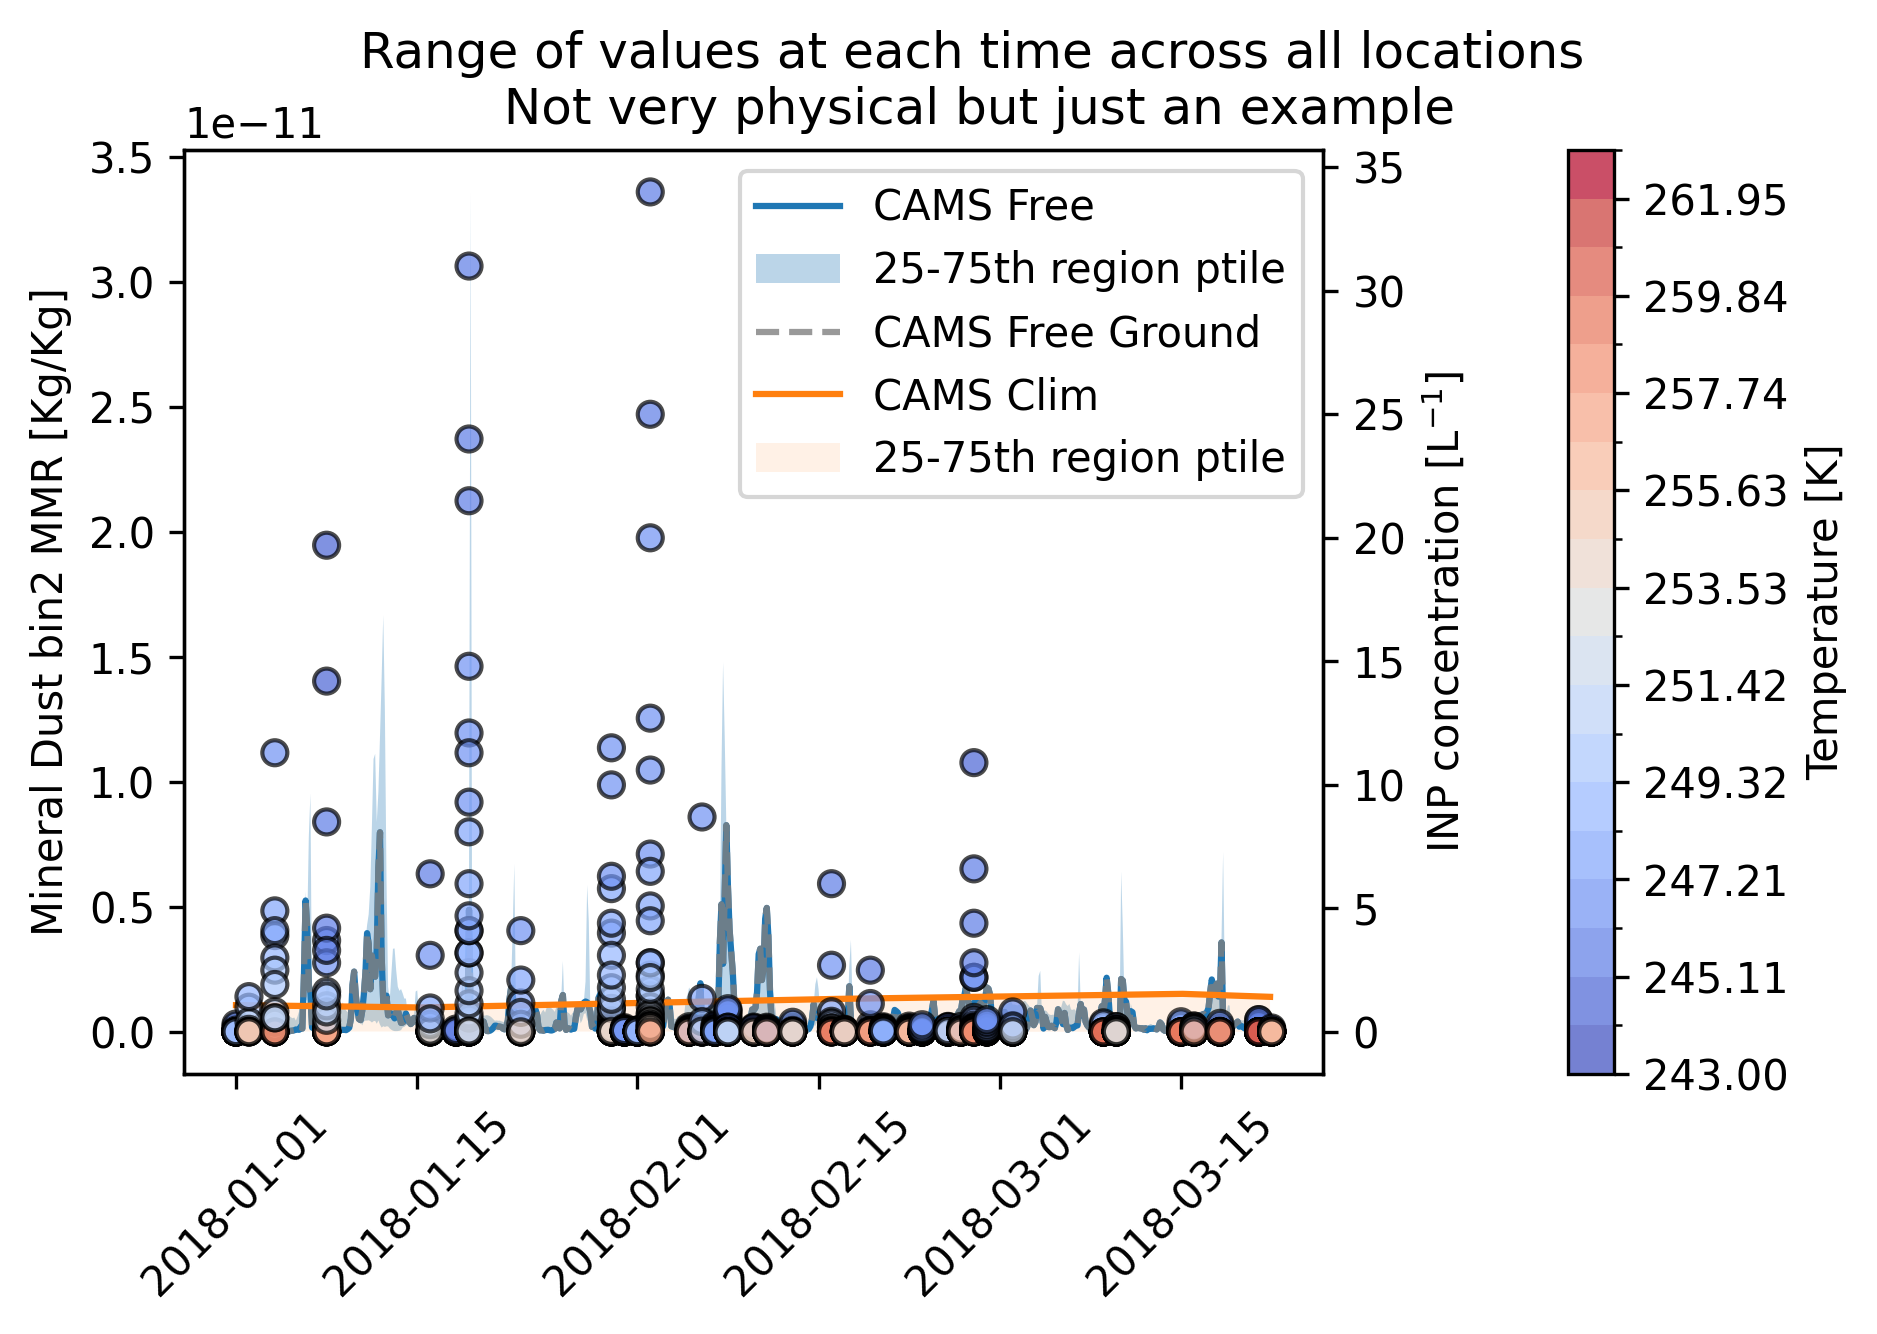

In [20]:
fig, ax = plt.subplots(dpi=300, figsize=(7,4))
ax2 = ax.twinx()

# Free run, prognostic aerosols
ax.plot(this_free_stats.time, this_free_stats.sel(quantile=0.5), label="CAMS Free")
ax.fill_between(this_free_stats.time, this_free_stats.sel(quantile=p1), this_free_stats.sel(quantile=p2), alpha=0.3, label=f"{p1*100:.0f}-{p2*100:.0f}th region ptile")
ax.plot(this_free_stats_ground.time, this_free_stats_ground.sel(quantile=0.5), label="CAMS Free Ground", color="gray", ls="--",
        alpha=0.8)
# Climatology
ax.plot(this_clim_stats.time, this_clim_stats.sel(quantile=0.5), label="CAMS Clim")
ax.fill_between(this_clim_stats.time, this_clim_stats.sel(quantile=p1), this_clim_stats.sel(quantile=p2), alpha=0.1, label=f"{p1*100:.0f}-{p2*100:.0f}th region ptile")
ax.legend()
ax.set_ylabel(f"{var.replace('_', ' ')} MMR [Kg/Kg]")

t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)
sc = ax2.scatter(inp_subs.time(), inp_subs.INP_conc.values,
            c=inp_subs.T(), label="INP obs", edgecolor='k', alpha=0.7,
            cmap=cmap, norm=norm)
ax2.set_ylabel(r"INP concentration [$\mathrm{L^{-1}}$]")
cbar = fig.colorbar(sc, ax=ax2, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.15)
# rotate date labels
ax.xaxis.set_tick_params(rotation=45)
fig.suptitle("Range of values at each time across all locations\n Not very physical but just an example")

Text(0.5, 0.99, 'Mineral Dust bin3 from model vs INP colocated')

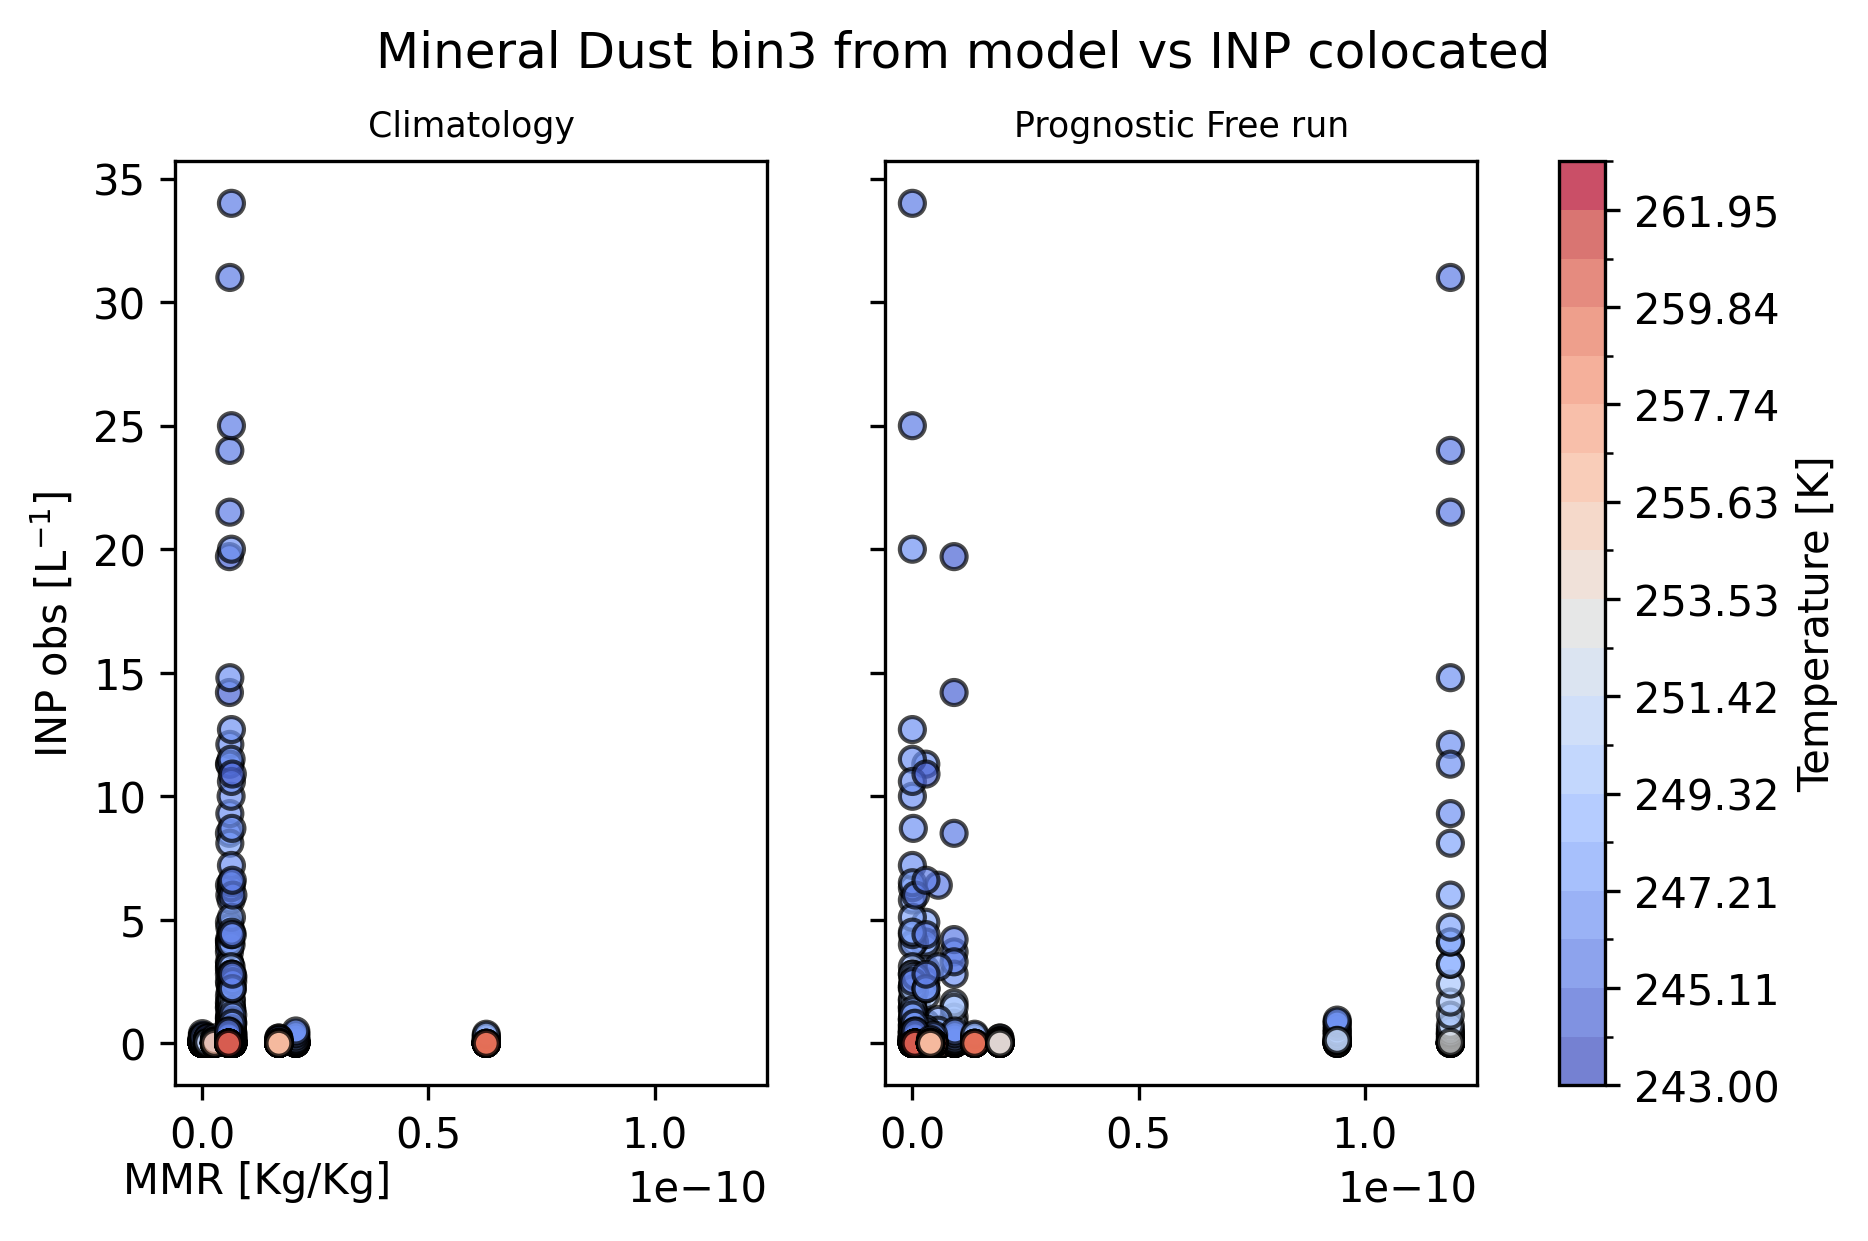

In [21]:
# Finally, this provides co-located data (time and space)

fig, axs = plt.subplots(ncols=2, dpi=300, figsize=(7,4),
                        sharey=True, sharex=True)
var = "Mineral_Dust_bin3"

ax1, ax2 = axs

t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)

sc = ax1.scatter(inp_subs.get_cams_clim(var_subset=var).values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = ax2.scatter(inp_subs.get_cams_free(var_subset=var).values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
cbar = fig.colorbar(sc, ax=axs, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.05)
fig.text(x=0.1, y=0.02, s=f"MMR [Kg/Kg]", ha="left")
ax1.set_ylabel(r"INP obs [$\mathrm{L^{-1}}$]")
ax1.set_title("Climatology", size="small")
ax2.set_title("Prognostic Free run", size="small")

fig.suptitle(f"{var.replace('_',' ')} from model vs INP colocated", y=0.99)

This shows the capability to colocate INP obs with model aerosol data. However, we don't want to compare aerosol mass mixing ratios to INP number concentrations.
From the aerosol data, we want to be able to add the mean diameter and the number concentration. This information can then go into an INP parametrisation to compare INP to INP.

## Apply a dust parametrisation and compare colocated INP for this subset

In [22]:
import src.physics.inp as inp_module
import src.physics.aerosol as aero_module


### We need information from the aerosol speciation to convert aerosol mass mixing ratios to number concentrations and to get the mean diameter

In [23]:
# Get the default aerosol specifications
aerosol_spec = aero_module.AerosolSpec()
aerosol_spec.ifsaero

{'Sea_Salt_bin1': IFSAeroSpecs(name='Sea_Salt_bin1', median=array([0.1002, 1.002 ]), shape=array([1.9, 2. ]), density=2180.0, rmin=0.0151, rmax=0.251, fact=array([0.96, 0.04]), m_act=0.0, nmodes=1),
 'Sea_Salt_bin2': IFSAeroSpecs(name='Sea_Salt_bin2', median=array([0.1002, 1.002 ]), shape=array([1.9, 2. ]), density=2180.0, rmin=0.251, rmax=2.51, fact=array([0.96, 0.04]), m_act=0.0, nmodes=1),
 'Sea_Salt_bin3': IFSAeroSpecs(name='Sea_Salt_bin3', median=array([0.1002, 1.002 ]), shape=array([1.9, 2. ]), density=2180.0, rmin=2.51, rmax=10.6, fact=array([0.96, 0.04]), m_act=0.0, nmodes=1),
 'Mineral_Dust_bin1': IFSAeroSpecs(name='Mineral_Dust_bin1', median=array([ 0.05,  0.42,  0.79, 16.2 ]), shape=array([2.2 , 1.18, 1.93, 1.53]), density=2610.0, rmin=0.03, rmax=0.55, fact=array([9.51361028e-01, 2.04141151e-02, 2.82245215e-02, 3.35774480e-07]), m_act=0.0, nmodes=1),
 'Mineral_Dust_bin2': IFSAeroSpecs(name='Mineral_Dust_bin2', median=array([ 0.05,  0.42,  0.79, 16.2 ]), shape=array([2.2 , 1.

In [24]:
# Get dust parametrization as example
inp_param_catalog = inp_module.INPParametrizationCatalog()
dust_param = inp_param_catalog.get_parametrization("Harrison2019")
marine_param = inp_param_catalog.get_parametrization("McCluskey2018")


In [25]:
# The site density function and the valid temperature range is defined in the parametrization object (defined in the catalog)
dust_param.site_density_func
dust_param.T_min, dust_param.T_max

(235.64999999999998, 269.65)

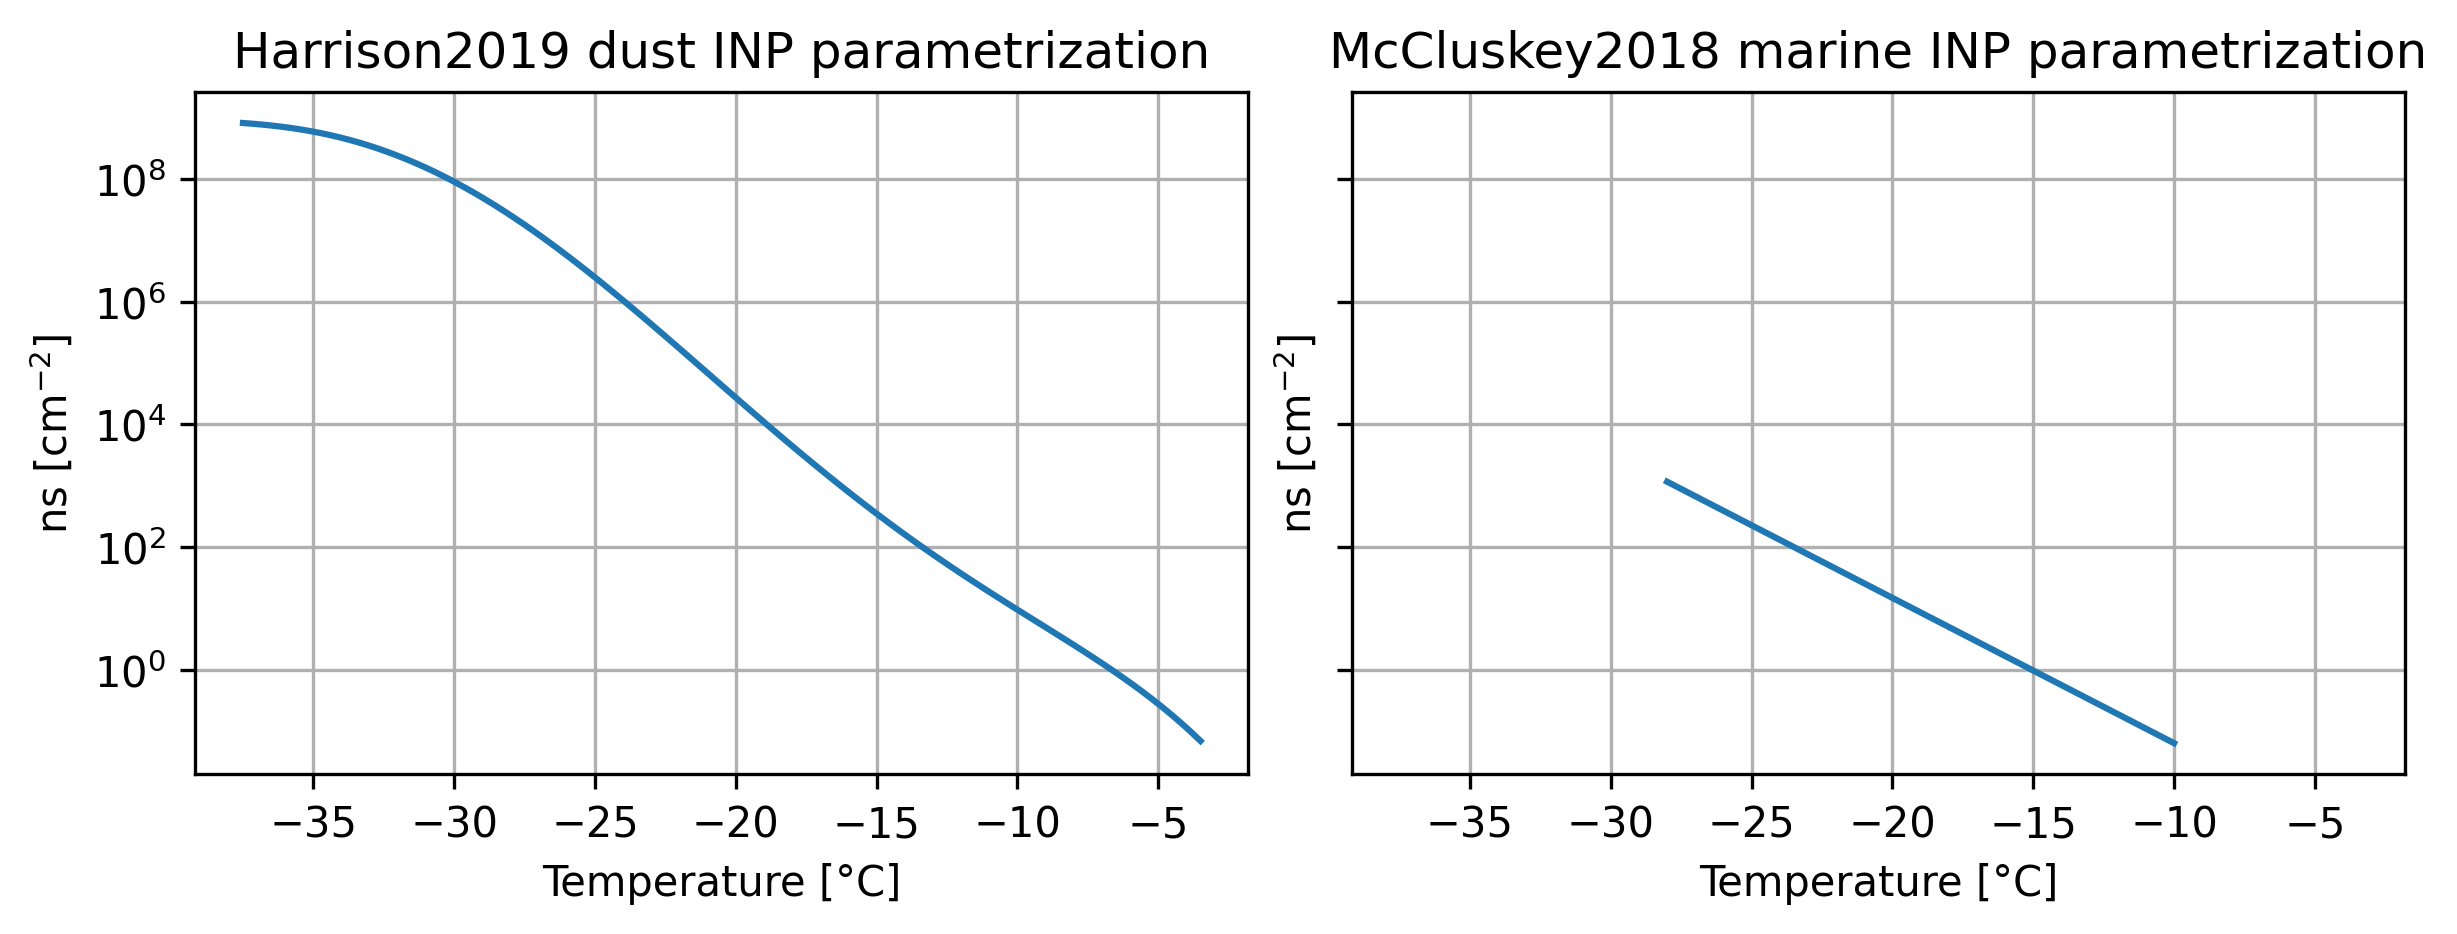

In [26]:
# Plot the inp (site density) parametrization
fig, axs = plt.subplots(ncols=2, dpi=300, figsize=(8,3), layout="constrained", sharey=True, sharex=True)

T_arr = np.linspace(dust_param.T_min, dust_param.T_max, 100)
ns = dust_param.site_density_func(T_arr)
ax = axs[0]
ax.plot(T_arr-273.15, ns)
ax.set_yscale("log")
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel(r"ns [$\mathrm{cm^{-2}}$]")
ax.set_title("Harrison2019 dust INP parametrization")
ax.grid()

T_arr = np.linspace(marine_param.T_min, marine_param.T_max, 100)
ns = marine_param.site_density_func(T_arr)
ax = axs[1]
ax.plot(T_arr-273.15, ns)
ax.set_yscale("log")
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel(r"ns [$\mathrm{cm^{-2}}$]")
ax.set_title("McCluskey2018 marine INP parametrization")
ax.grid()

In [27]:
# aerovars defines which aerosol variables are used for the parametrization (defined in the catalog)
dust_param.aerovars

['Mineral_Dust_bin1', 'Mineral_Dust_bin2', 'Mineral_Dust_bin3']

In [28]:
# Only 5% of dust is assumed to be feldspar, which is the component parametrised in Harrison2019
dust_param.aerosol_fraction

0.05

### Now we can apply the INP parametrisation and the aerosol spec to our subset of co-located cams aerosol data

In [29]:
inp_params = {}
inp_params["dust_kf"] = dust_param # my identifier
inp_params["marine"] = marine_param # my identifier

# Get co-located CAMS climatology INP concentrations for the subset of data, applying the parametrizations
# Returns a dataset with the INP concentrations per parametrization and the total INP concentration.
inp_subs.get_cams_clim_inp(
                          inp_params=inp_params,
                          aerosol_spec=aerosol_spec
)

<xarray.Dataset> Size: 76kB
Dimensions:  (obs_id: 1190)
Coordinates:
    lon      (obs_id) float64 10kB 110.5 110.5 110.5 110.5 ... 154.3 154.3 154.3
    lat      (obs_id) float64 10kB -66.3 -66.3 -66.3 -66.3 ... -50.2 -50.2 -50.2
  * obs_id   (obs_id) int64 10kB 200994 200995 200996 ... 203744 203745 203746
    col      (obs_id) int64 10kB 10 10 10 10 10 10 10 ... 16 16 16 16 16 16 16
    time     (obs_id) datetime64[ns] 10kB 2018-01-01 2018-01-01 ... 2018-03-22
Data variables:
    dust_kf  (obs_id) float64 10kB 0.0001909 4.848e-06 ... 8.757e-05 6.748e-05
    marine   (obs_id) float64 10kB 0.02367 0.001094 ... 0.003086 0.002617
    total    (obs_id) float64 10kB 0.02386 0.001099 ... 0.003174 0.002685

In [30]:
inp_subs.era5.data

<xarray.Dataset> Size: 659kB
Dimensions:  (col: 20, plev: 37, time: 216)
Coordinates:
    lat      (col) float64 160B -67.6 -67.5 -67.5 -67.4 ... -50.9 -54.6 -54.5
    lon      (col) float64 160B 62.8 62.8 62.9 62.9 ... 154.3 155.2 158.9 158.9
  * plev     (plev) float64 296B 100.0 200.0 300.0 ... 9.5e+04 9.75e+04 1e+05
  * time     (time) datetime64[ns] 2kB 2003-01-15 2003-02-15 ... 2020-12-15
Dimensions without coordinates: col
Data variables:
    sp       (time, col) float32 17kB ...
    t        (time, plev, col) float32 639kB ...
    z_sfc    (col) float32 80B ...
Attributes:
    CDI:          Climate Data Interface version 2.6.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Tue Jul 14 14:12:29 2026: cdo --eccodes -f nc4 -remapbil,./...
    CDO:          Climate Data Operators version 2.6.0 (https://mpimet.mpg.de...

Text(0.5, 0.99, 'Model total INP (Harrison2019, 5% feldspar & McCluskey2018 marine) vs INP colocated')

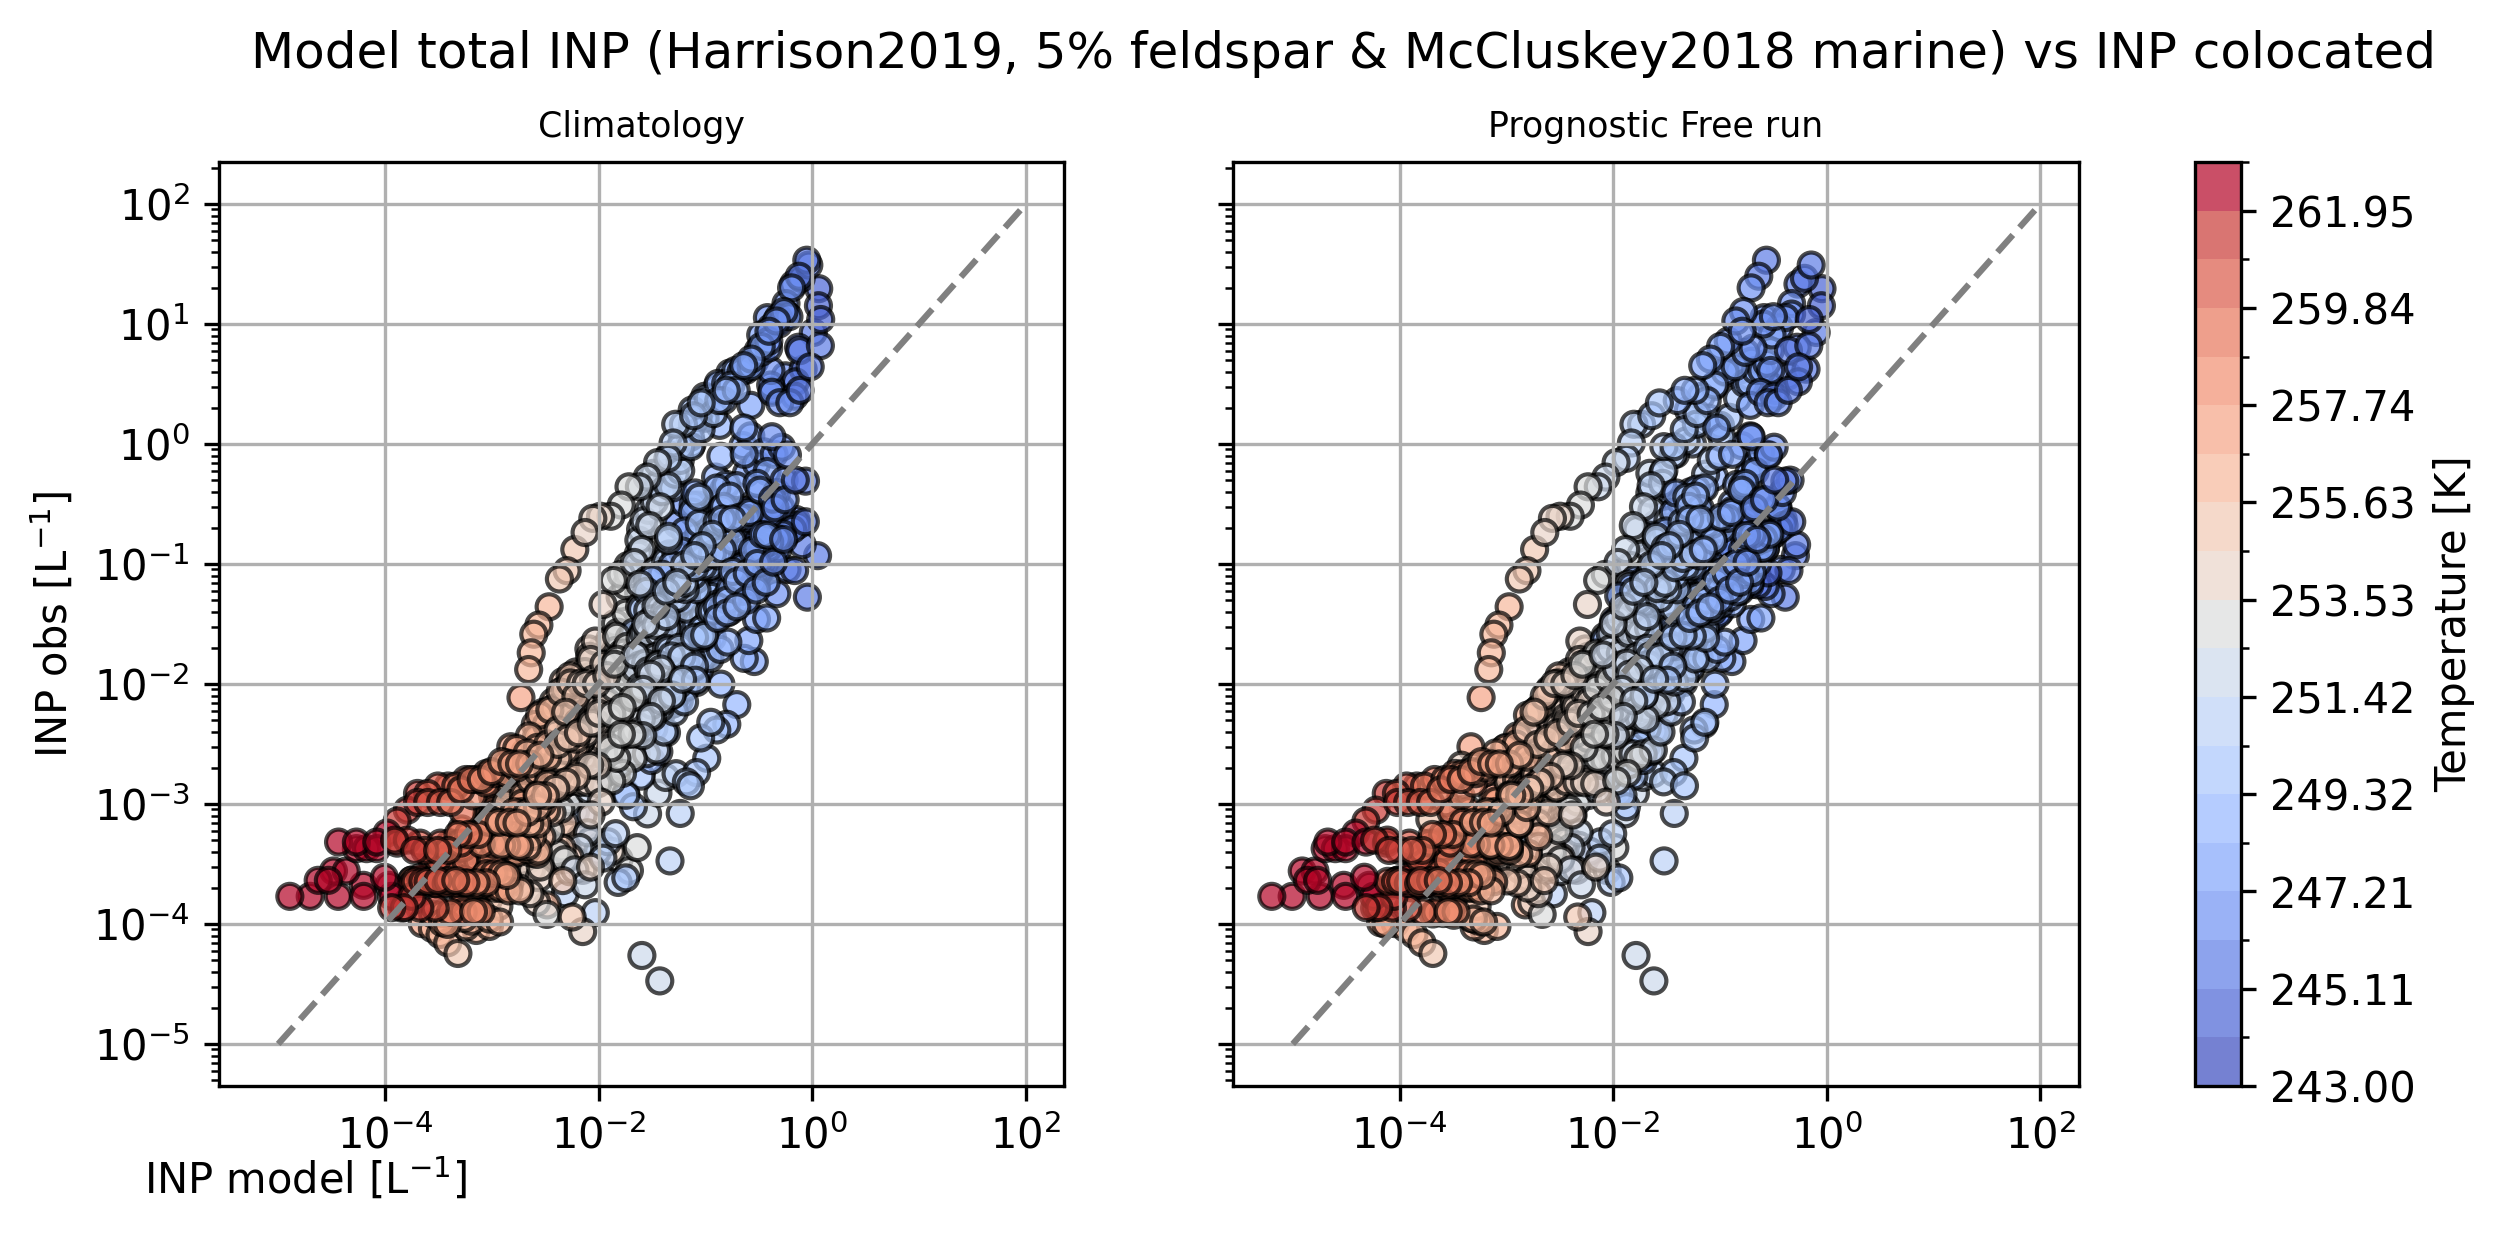

In [31]:
# Finally, compare model INP to colocated observations for climatology and free run

fig, axs = plt.subplots(ncols=2, dpi=300, figsize=(10,4),
                        sharey=True, sharex=True)

ax1, ax2 = axs

t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)

sc = ax1.scatter(inp_subs.get_cams_clim_inp(inp_params, aerosol_spec)["total"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = ax2.scatter(inp_subs.get_cams_free_inp(inp_params, aerosol_spec)["total"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
cbar = fig.colorbar(sc, ax=axs, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.05)
fig.text(x=0.1, y=0.02, s="INP model [$\mathrm{L^{-1}}$]", ha="left")
ax1.set_ylabel("INP obs [$\mathrm{L^{-1}}$]")
ax1.set_title("Climatology", size="small")
ax2.set_title("Prognostic Free run", size="small")

for ax in axs:
    ax.loglog()
    ax.grid()
    # Plot one to one line
    arr = np.logspace(-5,2)
    ax.plot(arr, arr, ls='--', color='grey', label="1:1 line")

fig.suptitle(f"Model total INP (Harrison2019, 5% feldspar & McCluskey2018 marine) vs INP colocated", y=0.99)

Text(0.5, 0.99, 'Model dust INP (Harrison2019, 5% feldspar) vs INP colocated')

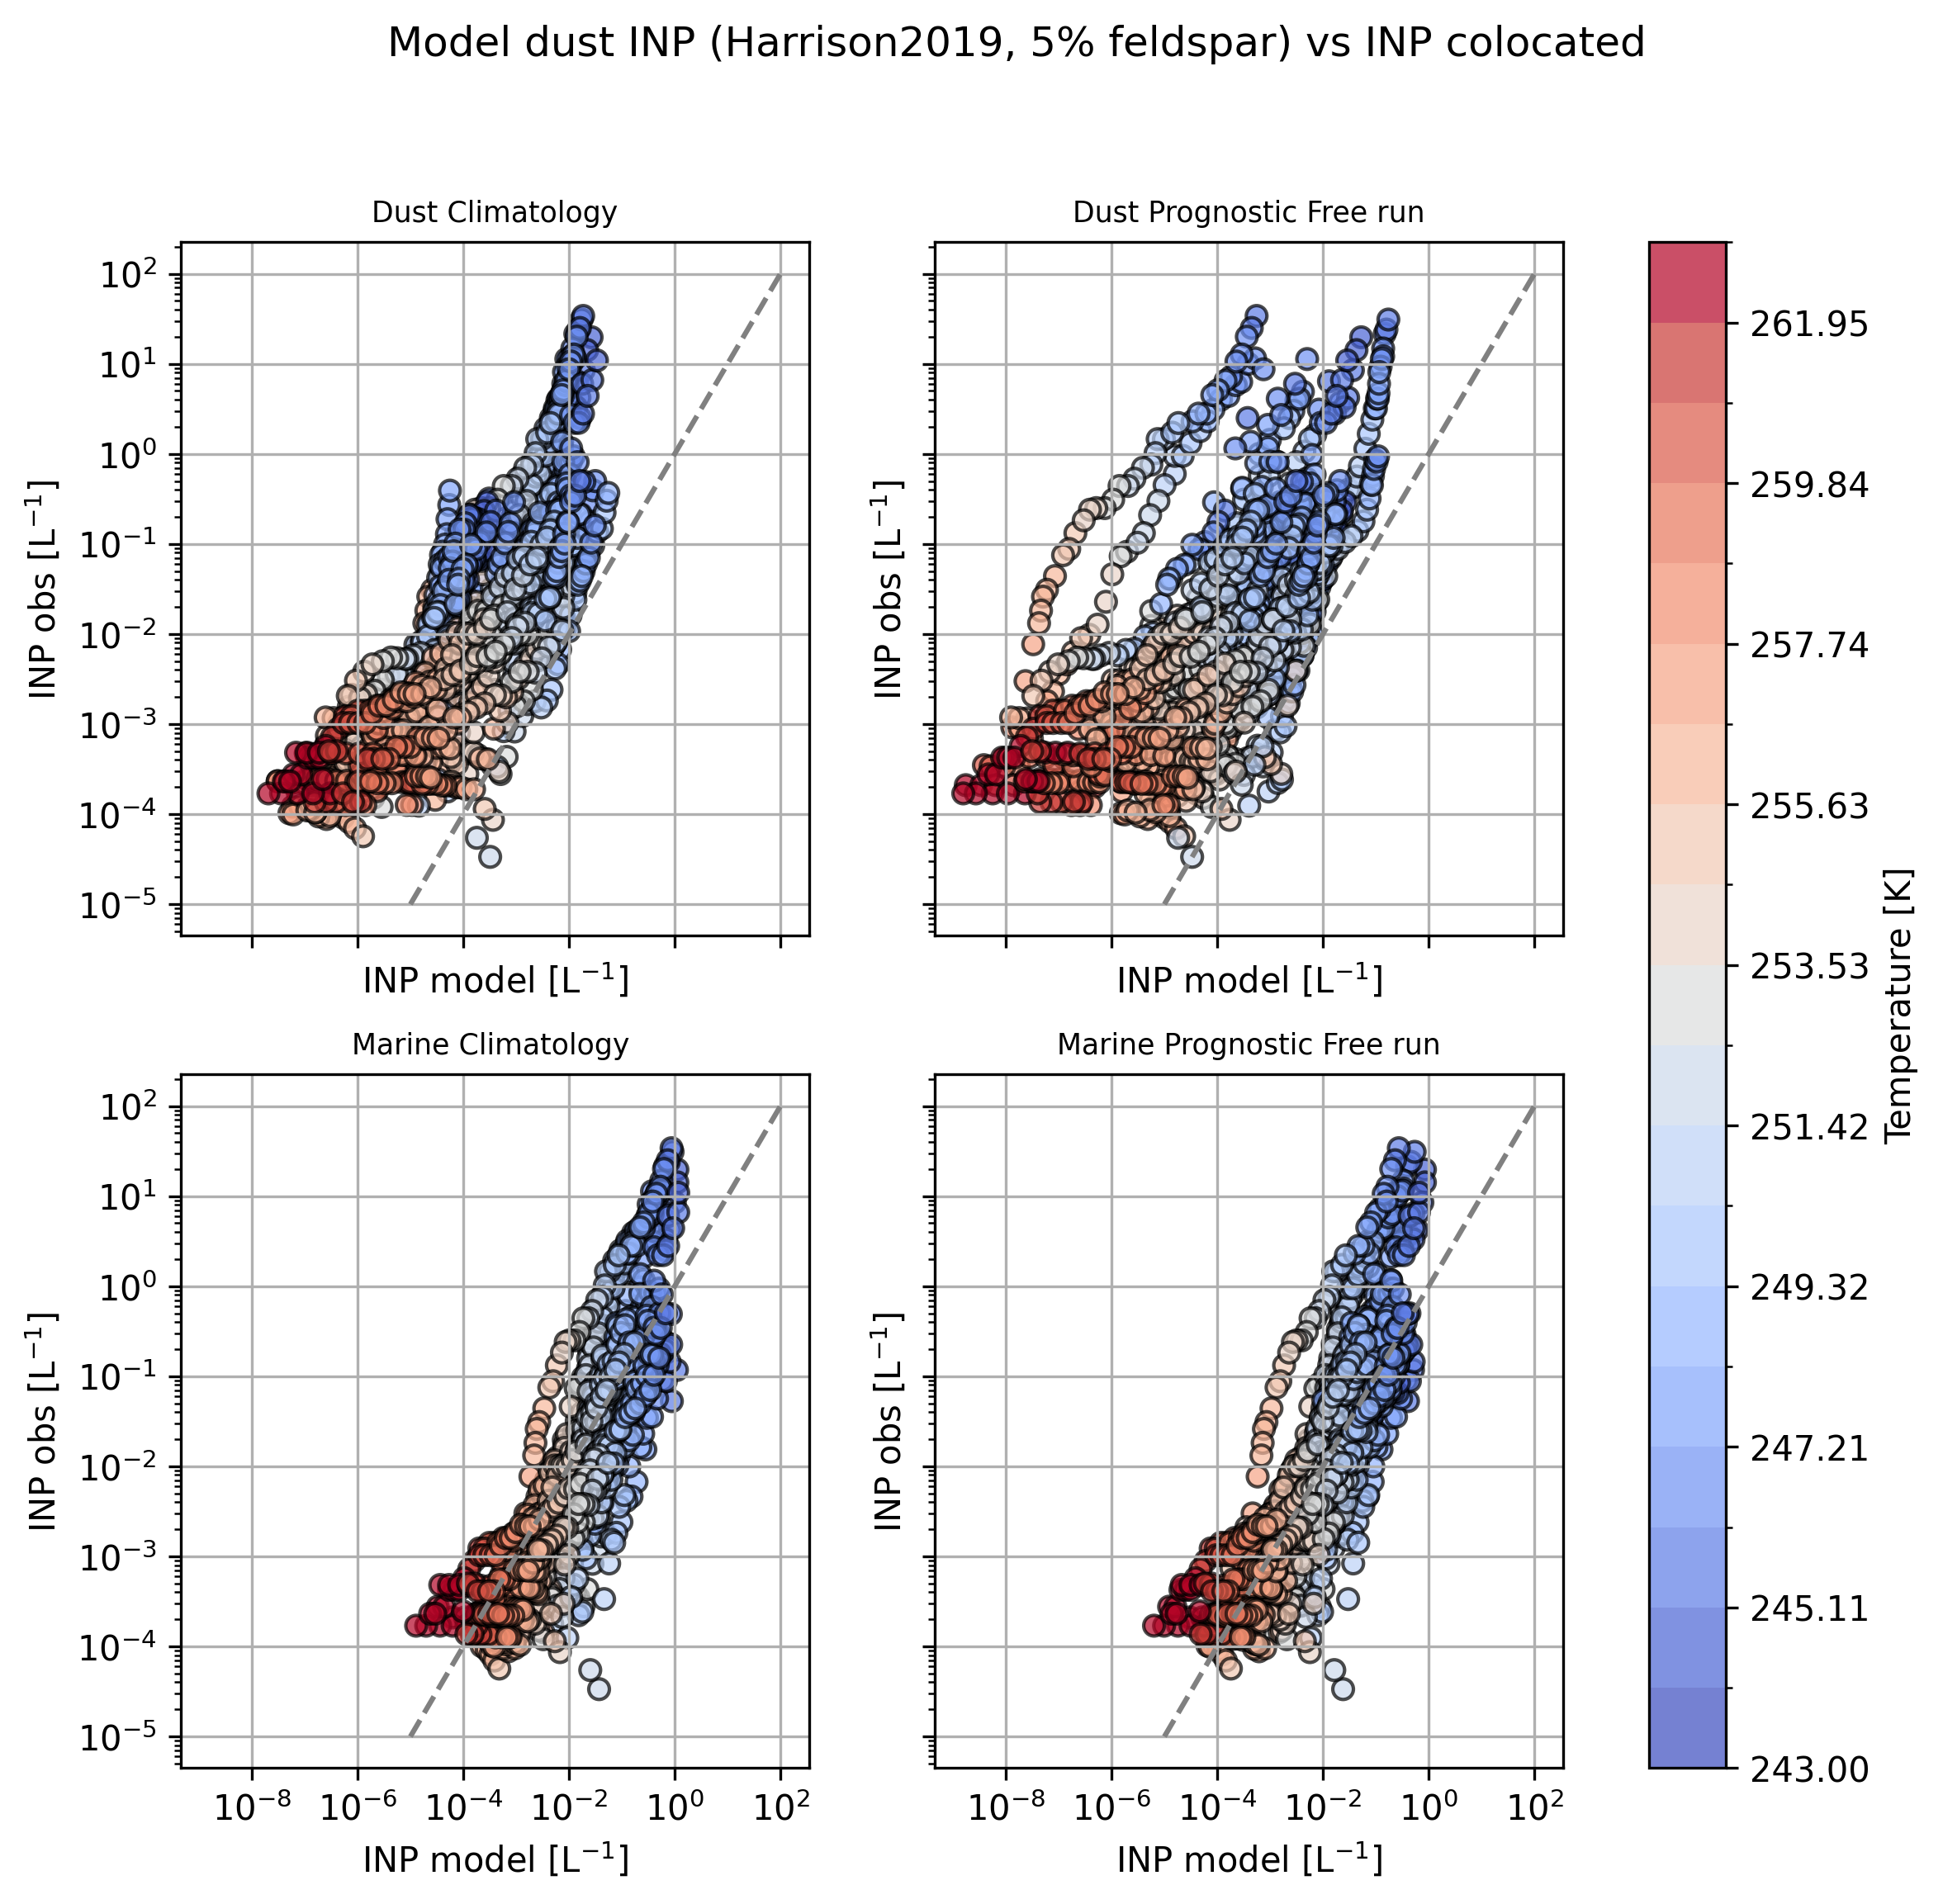

In [32]:
# Compare contributions from the different aerosol types in the model (compared to observed=total INP)

fig, axs = plt.subplots(ncols=2, nrows=2, dpi=300, figsize=(9,8),
                        sharey=True, sharex=True)



t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)

sc = axs[0,0].scatter(inp_subs.get_cams_clim_inp(inp_params, aerosol_spec)["dust_kf"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = axs[0,1].scatter(inp_subs.get_cams_free_inp(inp_params, aerosol_spec)["dust_kf"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)

sc = axs[1,0].scatter(inp_subs.get_cams_clim_inp(inp_params, aerosol_spec)["marine"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = axs[1,1].scatter(inp_subs.get_cams_free_inp(inp_params, aerosol_spec)["marine"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
cbar = fig.colorbar(sc, ax=axs, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.05)
# fig.text(x=0.1, y=0.02, s="INP model [$\mathrm{L^{-1}}$]", ha="left")

axs[0,0].set_title("Dust Climatology", size="small")
axs[0,1].set_title("Dust Prognostic Free run", size="small")
axs[1,0].set_title("Marine Climatology ", size="small")
axs[1,1].set_title("Marine Prognostic Free run", size="small")

for ax in axs.flat:
    ax.set_xlabel(r"INP model [$\mathrm{L^{-1}}$]")
    ax.set_ylabel(r"INP obs [$\mathrm{L^{-1}}$]")
    ax.loglog()
    ax.grid()
    # Plot one to one line
    arr = np.logspace(-5,2)
    ax.plot(arr, arr, ls='--', color='grey', label="1:1 line")

fig.suptitle(f"Model dust INP (Harrison2019, 5% feldspar) vs INP colocated", y=0.99)

### Test impact of increasing k-feldpar fraction. Does this increase the impact of dust?

In [33]:
inp_param_catalog = inp_module.INPParametrizationCatalog()
dust_param = inp_param_catalog.get_parametrization("Harrison2019")
dust_param_p50 = inp_param_catalog.get_parametrization("Harrison2019")
dust_param_p50.aerosol_fraction = 0.5
marine_param = inp_param_catalog.get_parametrization("McCluskey2018")


In [34]:

inp_params = {}
inp_params["dust_kf"] = dust_param # my identifier
inp_params["dust_kf_p50"] = dust_param_p50 # my identifier
inp_params["marine"] = marine_param # my identifier

Text(0.5, 0.98, 'Model INP from single species vs INP colocated')

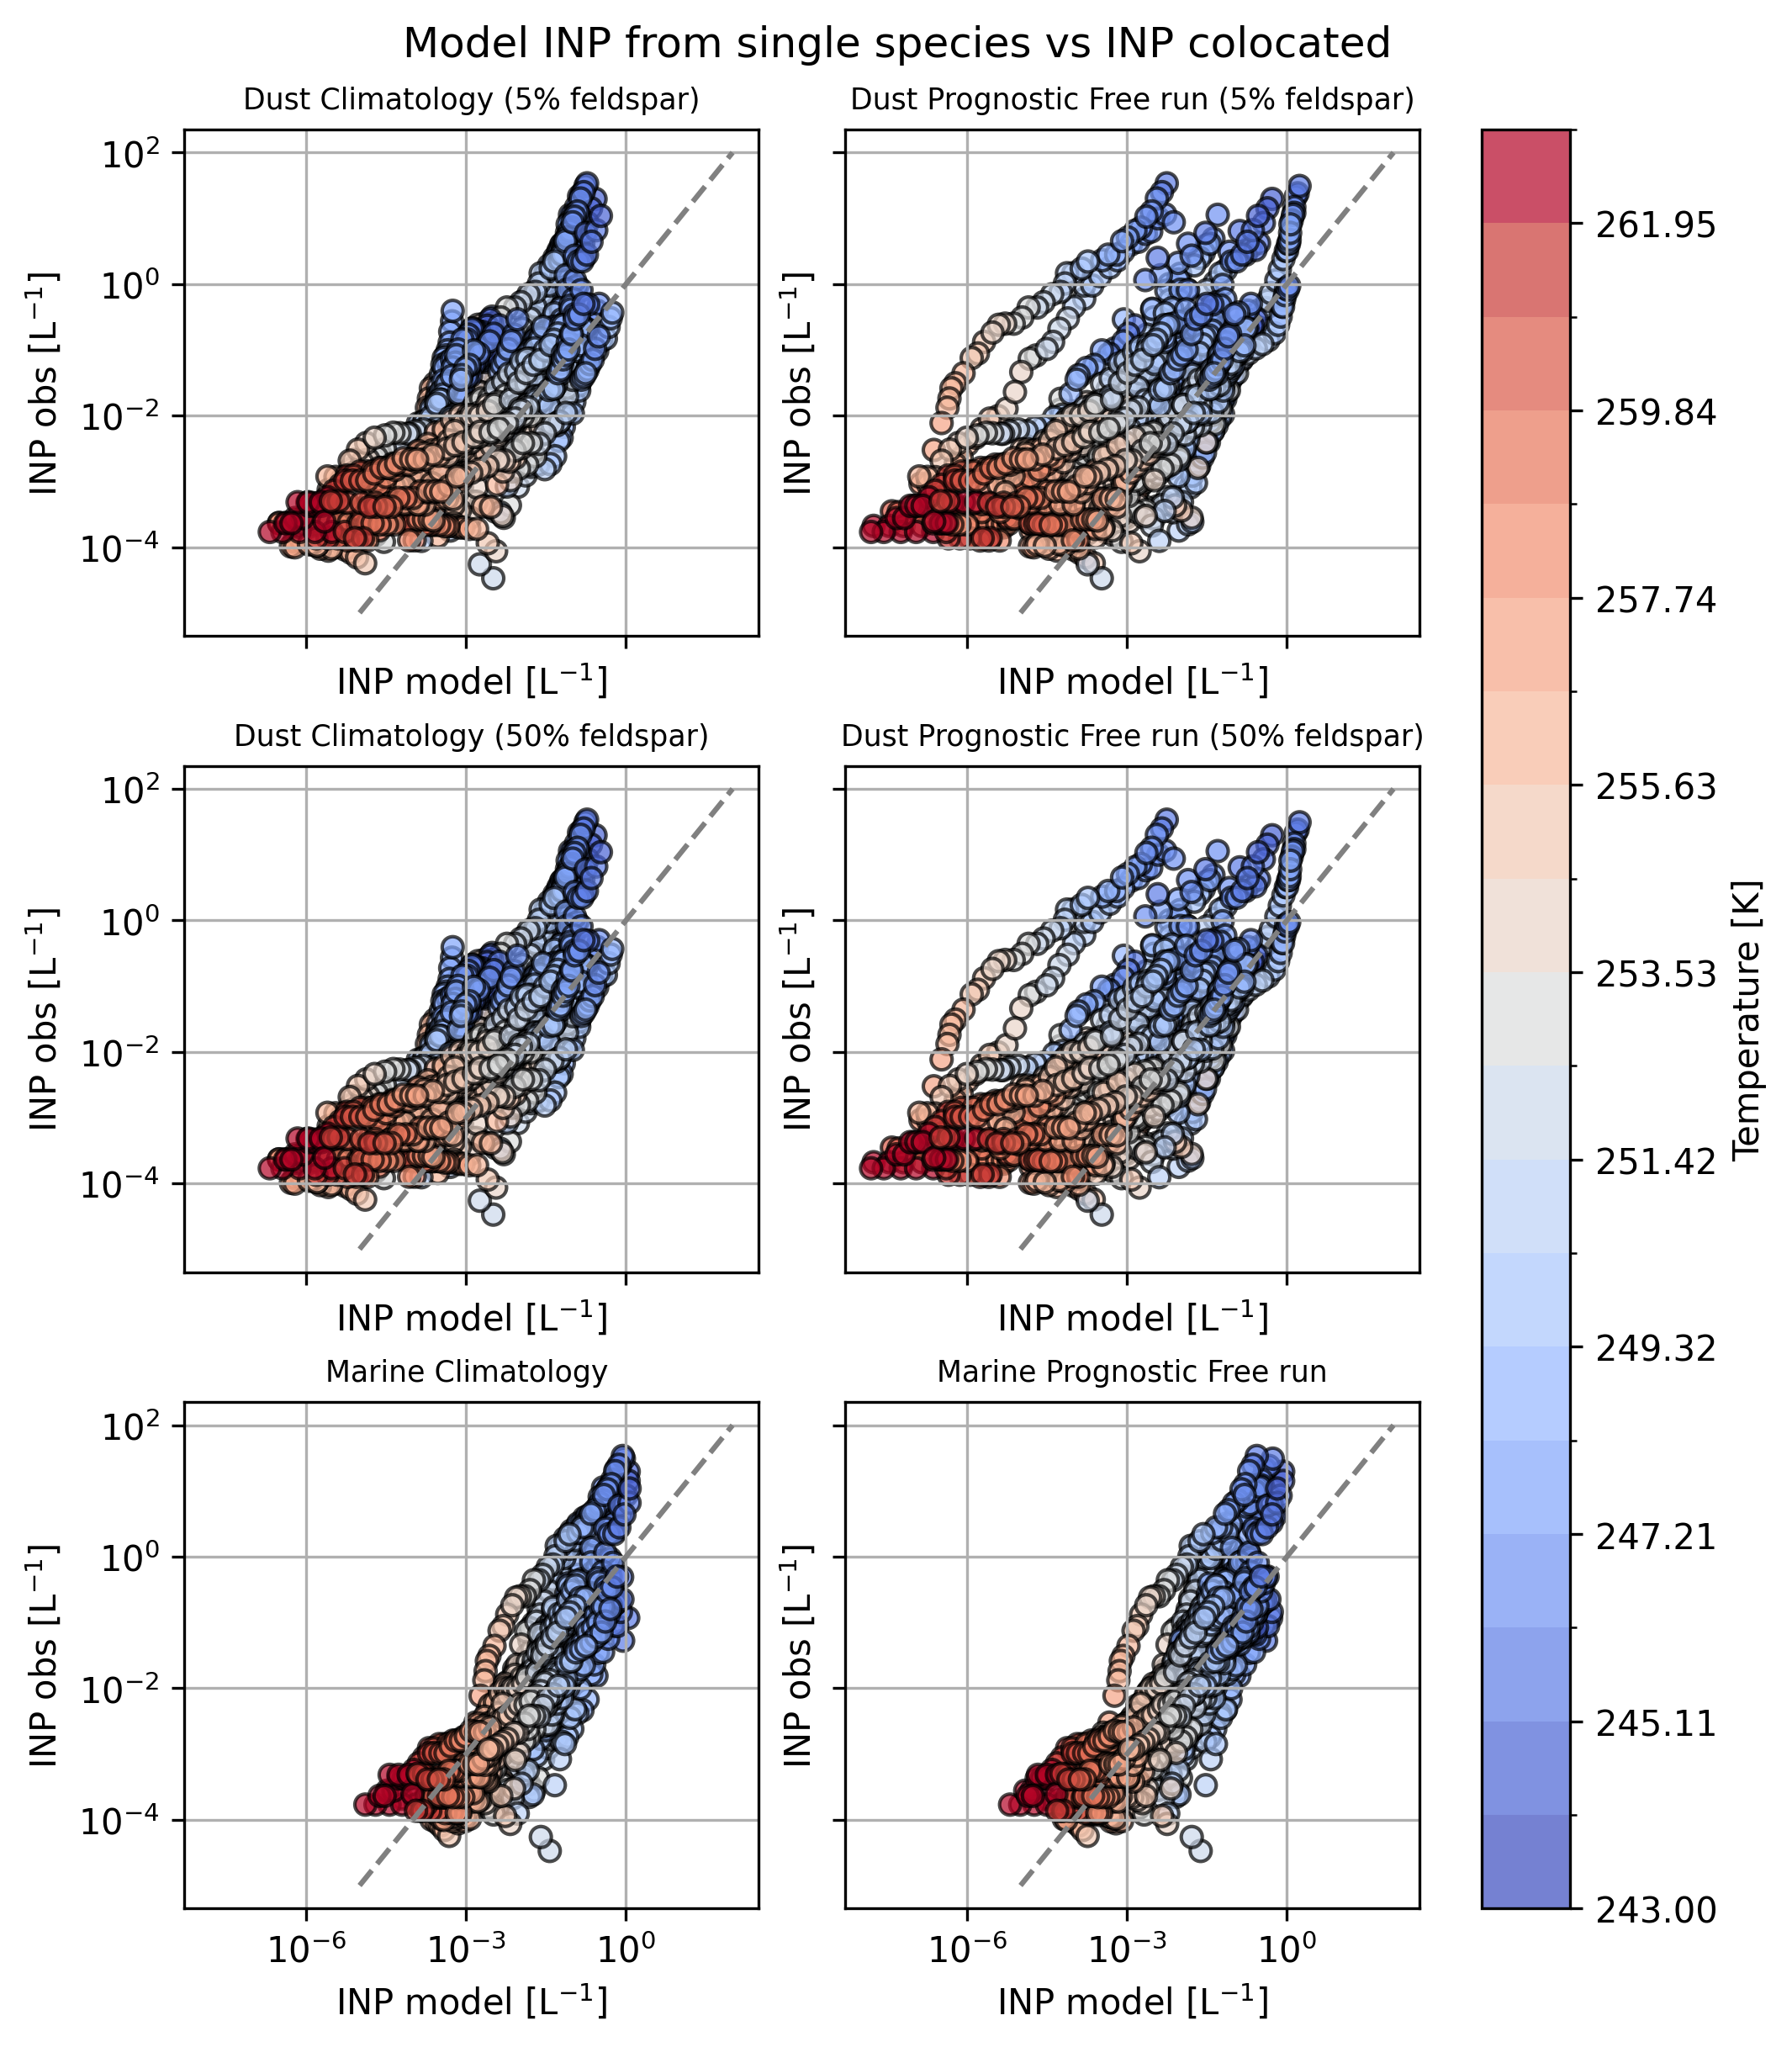

In [35]:
# Finally, this provides co-located data (time and space)

fig, axs = plt.subplots(ncols=2, nrows=3, dpi=300, figsize=(7,8), layout='constrained',
                        sharey=True, sharex=True)



t_levels = np.linspace(243, 263, 20)
cmap = plt.cm.coolwarm.copy()
from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm(t_levels, cmap.N)

sc = axs[0,0].scatter(inp_subs.get_cams_clim_inp(inp_params, aerosol_spec)["dust_kf"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = axs[0,1].scatter(inp_subs.get_cams_free_inp(inp_params, aerosol_spec)["dust_kf"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)

sc = axs[1,0].scatter(inp_subs.get_cams_clim_inp(inp_params, aerosol_spec)["dust_kf_p50"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = axs[1,1].scatter(inp_subs.get_cams_free_inp(inp_params, aerosol_spec)["dust_kf_p50"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)

sc = axs[2,0].scatter(inp_subs.get_cams_clim_inp(inp_params, aerosol_spec)["marine"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
sc = axs[2,1].scatter(inp_subs.get_cams_free_inp(inp_params, aerosol_spec)["marine"].values, inp_subs.INP_conc.values,
                c=inp_subs.T(),
                marker='o', edgecolor='k', alpha=0.7,
                cmap=cmap, norm=norm)
cbar = fig.colorbar(sc, ax=axs, orientation='vertical',
                    norm=norm,
                    label="Temperature [K]", pad=0.05)
# fig.text(x=0.1, y=0.02, s="INP model [$\mathrm{L^{-1}}$]", ha="left")

axs[0,0].set_title("Dust Climatology (5% feldspar)", size="small")
axs[0,1].set_title("Dust Prognostic Free run (5% feldspar)", size="small")
axs[1,0].set_title("Dust Climatology (50% feldspar)", size="small")
axs[1,1].set_title("Dust Prognostic Free run (50% feldspar)", size="small")
axs[2,0].set_title("Marine Climatology ", size="small")
axs[2,1].set_title("Marine Prognostic Free run", size="small")

for ax in axs.flat:
    ax.set_xlabel(r"INP model [$\mathrm{L^{-1}}$]")
    ax.set_ylabel(r"INP obs [$\mathrm{L^{-1}}$]")
    ax.loglog()
    ax.grid()
    # Plot one to one line
    arr = np.logspace(-5,2)
    ax.plot(arr, arr, ls='--', color='grey', label="1:1 line")

fig.suptitle(f"Model INP from single species vs INP colocated")

# AERONET colocation
There is a similar interface, but instead of all observations treated independently, each Aeronet station is a collection of observations.
For the climatology, the AOD is calculated on the fly from the aerosol data. For the cams_free it uses the AOD from the model output.

In [6]:
from src.main import build_aeronet_collection
aeronet_coll = build_aeronet_collection()

Loading Aeronet collection from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/aeronet/monthly/AOD/20260701/lev20
Found synthesis file /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/aeronet/monthly/AOD/20260701/lev20/synth_files/synthfile_monthly_lev20_20260726.parquet
Loading CAMS climatology from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/cams_clim/point_files/aerosol_cams_climatology_49r2_1951-2019_4D_aeronet-monthly_AOD-20260701.nc
Loading CAMS free output from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/cams_free/*_aeronet-monthly_AOD-20260701_zarr
Opening archives as zarr
Getting surface fields
Loading MACv2-SP from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/macv2_sp/point_files/MACv2-SP_2Dfields_T63_1km_1980_2020_aeronet-monthly_AOD-20260701.nc
Loading MACv2 natural climatology from /etc/ecmwf/nfs/dh1_home_b/papa/Documents/explore_inp/inpdb_coloc/data/mac

In [7]:
region_bounds_coteazur = dict(lon_west=4, lon_east=8, lat_south=42, lat_north=45)
region_bounds_swi = dict(lon_west=6, lon_east=10.5, lat_south=45.5, lat_north=48)

# Safer execution profile for notebook stability:
# - month chunks reduce peak memory
# - single worker avoids native-lib thread contention
aeronet_coll_coteazur = aeronet_coll.get_region_subset(**region_bounds_coteazur)

# This is what takes the most calculations. Successive calls are faster because results are cached
# n_workers > 1 speeds up things with parallel calulations,
# but too high values cause memory to explode in jupyter notebook
aeronet_coll_coteazur.calculate_aod(n_workers=2, show_progress=True)

AOD chunks:   0%|          | 0/41 [00:00<?, ?it/s]

Adding volcanic aerosol AOD from GloSSAC dataset


<xarray.Dataset> Size: 2MB
Dimensions:           (wavelength: 8, time: 492, station_name: 16)
Coordinates:
  * wavelength        (wavelength) float64 64B 340.0 380.0 ... 870.0 1.02e+03
  * time              (time) datetime64[ns] 4kB 1980-01-15 ... 2020-12-15
  * station_name      (station_name) <U17 1kB 'Avignon' 'Calern_OCA' ... 'Vinon'
    lat               (station_name) float64 128B 43.93 43.75 ... 43.68 43.71
    lon               (station_name) float64 128B 4.878 6.923 ... 7.329 5.759
    alt               float64 8B 39.5
Data variables:
    AOD_tropo         (wavelength, time, station_name) float64 504kB 0.1506 ....
    Abs_total         (wavelength, time, station_name) float64 504kB 0.009748...
    AOD_volc_glossac  (time, station_name, wavelength) float64 504kB 0.01169 ...
    AOD               (wavelength, time, station_name) float64 504kB 0.1623 ....

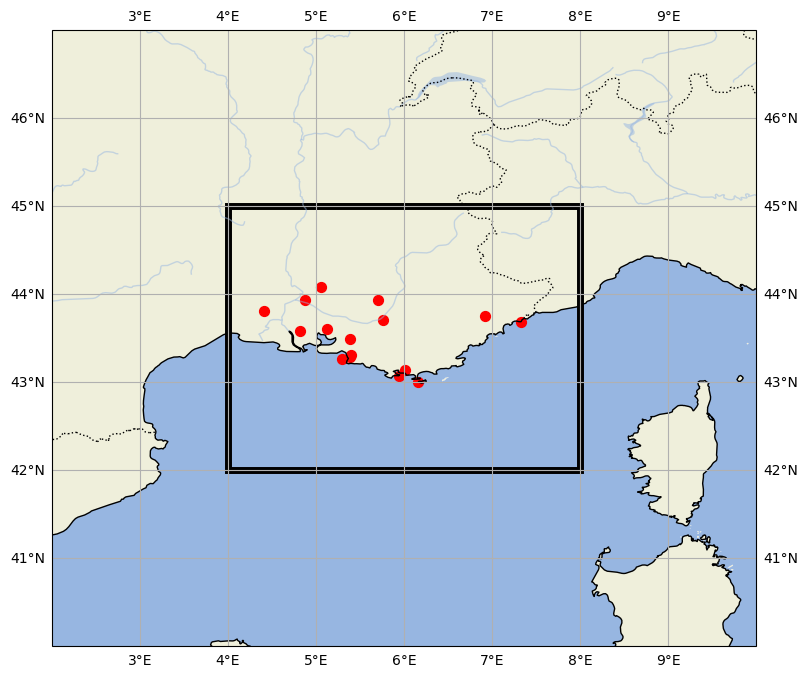

In [8]:
# Show stations on the map
def plot_aeronet_stations(lonlat_coords, region_bounds, ax=None):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})


    # Add features to the map
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    # Add terrain features
    ax.add_feature(cfeature.LAKES, alpha=0.5)
    ax.add_feature(cfeature.RIVERS, alpha=0.5)
    # Add regional borders
    ax.add_feature(cfeature.BORDERS, linestyle=':')


    # Plot the stations
    ax.scatter(lonlat_coords[:,0], lonlat_coords[:,1], color='red', s=50, transform=ccrs.PlateCarree())
    # Set the extent of the map using region_bounds
    dcoords=2
    ax.set_extent([region_bounds['lon_west']-dcoords, region_bounds['lon_east']+dcoords,
                np.clip(region_bounds['lat_south']-dcoords, a_min=-90, a_max=90),
                np.clip(region_bounds['lat_north']+dcoords, a_min=-90, a_max=90)],
                crs=ccrs.PlateCarree())
    # draw region square as patch
    from matplotlib.patches import Rectangle
    rect = Rectangle((region_bounds['lon_west'], region_bounds['lat_south']),
                    region_bounds['lon_east'] - region_bounds['lon_west'],
                    region_bounds['lat_north'] - region_bounds['lat_south'],
                    linewidth=5, edgecolor='black',
                    facecolor='none', transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    # Add gridlines
    ax.gridlines(draw_labels=True)

    return ax

import numpy as np
ax = plot_aeronet_stations(
    np.asarray(aeronet_coll_coteazur.stations_coords),
    region_bounds_coteazur
)

### Note on MERRA2 and MACV2-SP
These are other sources for AOD , they don't matter much here, but are some other historical datasets that can be for data in the 1980s or 1990s
* The covered time period can be restricted anyway in the config by changing the coverage for the era5 data ini_year and end_year - it might need some adjustment of the load_merra2 and load_macv2_sp to restrict time periods.
#### MERRA2 and MACV2-SP can also be ignored (not loaded)
by just calling at the beginning, when constructing the collection:
```python
aeronet_coll = build_aeronet_collection(macv2sp_aeronet_path = "", merra2_aeronet_path = "")
```

No valid bracketing wavelengths found for 340 nm within 200 nm
Filling 469 NaN points at 500 nm using 440.0 and 675.0 nm
Filling 1036 NaN points at 550 nm using 500.0 and 675.0 nm
No valid bracketing wavelengths found for 1020 nm within 200 nm


/home/papa/_venvs/notes_py311/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


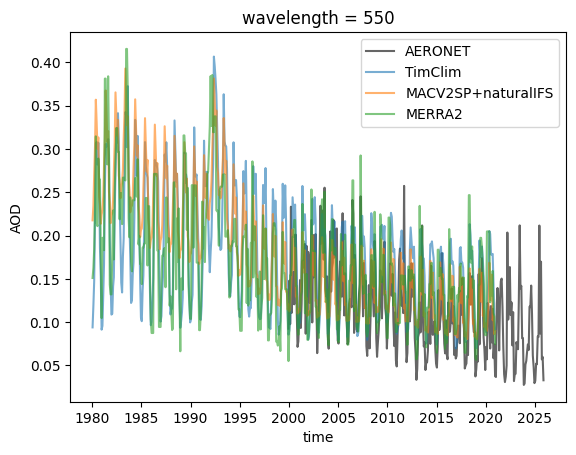

In [9]:
wl = 550
aeronet_coll_coteazur.get_obs_aod().mean(dim="station_name")["AOD"].sel(wavelength_nm=wl).plot(label="AERONET", color="black", alpha=0.6)
aeronet_coll_coteazur.calculate_aod()["AOD"].mean(dim="station_name").sel(wavelength=wl).plot(label="TimClim", alpha=0.6)
aeronet_coll_coteazur.calculate_aod(source="macv2sp")["AOD"].mean(dim="station_name").sel(wavelength=wl).plot(label="MACV2SP+naturalIFS", alpha=0.6)
aeronet_coll_coteazur.calculate_aod(source="merra2")["AOD"].mean(dim="station_name").sel(wavelength=wl).plot(label="MERRA2", alpha=0.6)
import matplotlib.pyplot as plt
plt.legend()

In [10]:
# Aeronet stations can be selected with
stations_selection = ["Capo_Verde", "Dakar", "Izana", "Banizoumbou"]
acoll_subs = aeronet_coll.get_stations_subset(stations_selection)

Filling 480 NaN points at 550 nm using 500.0 and 675.0 nm
Filling 583 NaN points at 550 nm using 440.0 and 675.0 nm
Finished computing AODs


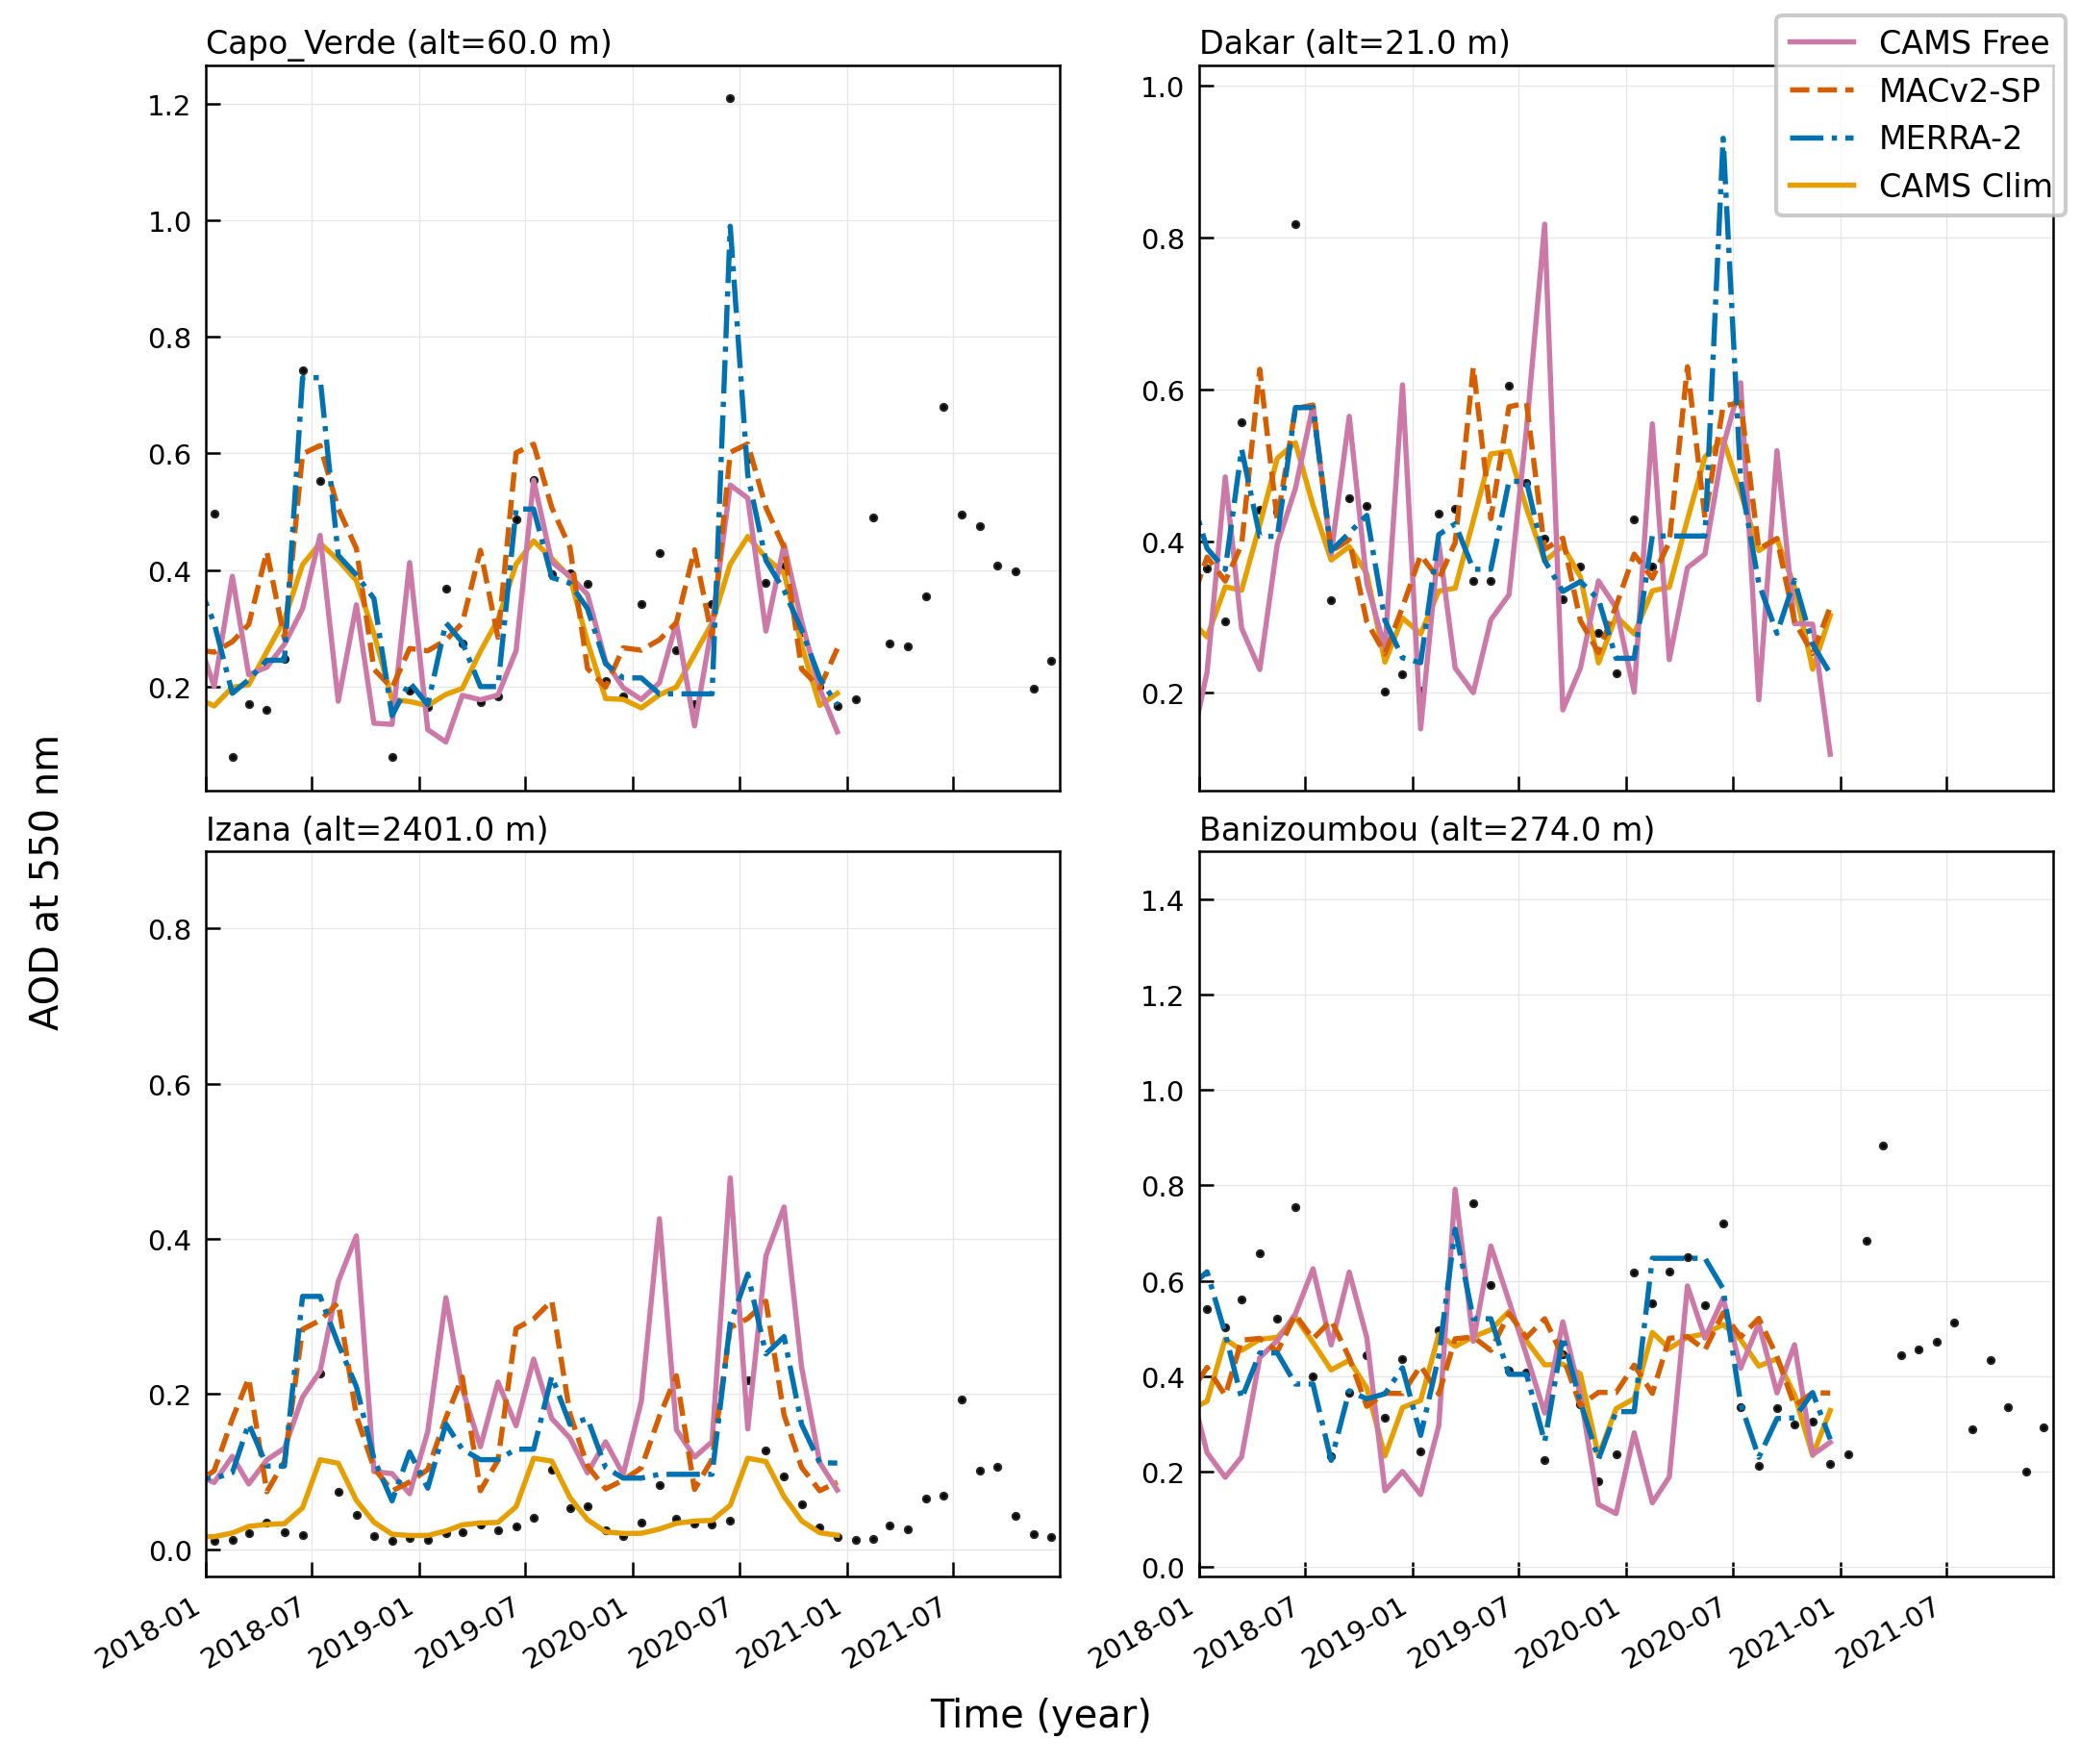

In [26]:
wl_nm = 550

timemin = np.datetime64("2018-01-01")
timemax = np.datetime64("2021-12-31")

okabe_ito_palette = {
    "orange": "#E69F00",
    "skyblue": "#56B4E9",
    "green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "red": "#D55E00",
    "purple": "#CC79A7",
}

all_aeronet = acoll_subs.get_obs_aod(aod_wl=[wl_nm], ae_wl=[])["AOD"].sel(wavelength_nm=wl_nm)
all_clim = acoll_subs.calculate_aod(source="cams_clim", wavelengths_nm=(wl_nm,), n_workers=2)["AOD"].squeeze(dim="wavelength")
all_cams_free = acoll_subs.calculate_aod(source="cams_free", wavelengths_nm=(wl_nm,), n_workers=2).squeeze(dim="wavelength")
all_macv2sp = acoll_subs.calculate_aod(source="macv2sp", wavelengths_nm=(wl_nm,))["AOD"].squeeze(dim="wavelength")
all_macv2sp_cams = acoll_subs.calculate_aod(source="macv2sp+cams", wavelengths_nm=(wl_nm,))["AOD"].squeeze(dim="wavelength")
all_merra2 = acoll_subs.calculate_aod(source="merra2", wavelengths_nm=(wl_nm,))["AOD"].squeeze(dim="wavelength")
print("Finished computing AODs")

ncols = 2
nrows = 2

trolling = 1

colors = {
    "CAMS Clim": okabe_ito_palette["orange"],
    "CAMS Free": okabe_ito_palette["purple"],
    "MACv2-SP":  okabe_ito_palette["red"],
    "MACv2-SP_cams":  okabe_ito_palette["green"],
    "MERRA-2":   okabe_ito_palette["blue"],
    "AERONET":   "k",
}

lstyles = {
    "CAMS Clim": "-",
    "CAMS Free": "-",
    "MACv2-SP":  "--",
    "MACv2-SP_cams":  ":",
    "MERRA-2":   "-.",
    "AERONET":   "-",
}

ylims = {
    "nfr" : {"top" : 0.42},
    "lei" : {"top" : 0.45}
}

pub_rc = {
    "font.family":       "sans-serif",
    "font.size":          8,
    "axes.titlesize":     8,
    "axes.labelsize":     8,
    "xtick.labelsize":    7,
    "ytick.labelsize":    7,
    "legend.fontsize":    8,
    "lines.linewidth":    1.3,
    "axes.linewidth":     0.6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
}

with plt.rc_context(pub_rc):
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7.1, 6.0),   # ~180 mm wide — typical double-column journal figure
        dpi=300,
        sharex=True, sharey=False,
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, station in enumerate(stations_selection):
        ax = axes_flat[i]

        station_sel = [station]
        this_aeronet  = all_aeronet.sel(station_name=station_sel).mean(dim="station_name")
        this_clim = all_clim.sel(station_name=station_sel).mean(dim="station_name")
        this_cams_free = all_cams_free.sel(station_name=station_sel).mean(dim="station_name")
        this_macv2sp  = all_macv2sp.sel(station_name=station_sel).mean(dim="station_name")
        this_macv2sp_cams  = all_macv2sp_cams.sel(station_name=station_sel).mean(dim="station_name")
        this_merra2   = all_merra2.sel(station_name=station_sel).mean(dim="station_name")


        ax.scatter(this_aeronet.time, this_aeronet,
                   c="k", alpha=0.85, s=1.5, rasterized=True)
        # ax.plot(this_aeronet.time,
        #         this_aeronet.rolling(time=trolling, center=True, min_periods=11).mean(),
        #         color=colors["AERONET"], label="AERONET", ls=lstyles["AERONET"], lw=2)

        ax.plot(this_clim.time,
                this_clim.rolling(time=trolling, center=True).mean(),
                color=colors["CAMS Clim"], ls=lstyles["CAMS Clim"], label="CAMS Clim")
        ax.plot(this_cams_free.time,
                this_cams_free.rolling(time=trolling, center=True).mean(),
                color=colors["CAMS Free"], ls=lstyles["CAMS Free"], label="CAMS Free")
        # ax.plot(this_macv2sp_cams.time,
        #         this_macv2sp_cams.rolling(time=trolling, center=True).mean(),
        #         color=colors["MACv2-SP_cams"], ls=lstyles["MACv2-SP_cams"], label=r"MACv2-SP$^\dagger$")
        ax.plot(this_macv2sp.time,
                this_macv2sp.rolling(time=trolling, center=True).mean(),
                color=colors["MACv2-SP"], ls=lstyles["MACv2-SP"], label="MACv2-SP")
        ax.plot(this_merra2.time,
                this_merra2.rolling(time=trolling, center=True).mean(),
                color=colors["MERRA-2"], ls=lstyles["MERRA-2"], label="MERRA-2")

        # Panel label + title
        station_altitude = float(acoll_subs.stations[station].alt)
        ax.set_title(f"{station} (alt={station_altitude} m)", loc="left", pad=3)
        ax.grid(True, lw=0.3, color="0.9")
        ax.set_axisbelow(True)

        ax.set_xlim(timemin, timemax)


    # Shared legend — placed in the empty last slot if there is one, else below figure
    handles, labels = axes_flat[0].get_legend_handles_labels()
    # Move first label to the end
    handles = handles[1:] + [handles[0]]
    labels = labels[1:] + [labels[0]]

    n_unused = len(axes_flat) - len(stations_selection)
    if n_unused > 0:
        axes_flat[-1].set_visible(False)
        axes_flat[-1].set_visible(True)
        axes_flat[-1].axis("off")
        axes_flat[-1].legend(handles, labels, loc="center", frameon=True,
                             edgecolor="0.75", borderpad=0.8)
    else:
        fig.legend(handles, labels, loc="upper right", ncol=1,
                   frameon=True, edgecolor="0.75")

    fig.supxlabel("Time (year)")
    fig.supylabel(f"AOD at {wl_nm} nm")

    fig.autofmt_xdate()





In [21]:
this_cams_free.time

<xarray.DataArray 'time' (time: 492)> Size: 4kB
array(['2003-01-01T03:00:00.000000000', '2003-01-01T03:00:00.000000000',
       '2003-01-01T03:00:00.000000000', ..., '2020-10-15T00:00:00.000000000',
       '2020-11-15T00:00:00.000000000', '2020-12-15T00:00:00.000000000'],
      shape=(492,), dtype='datetime64[ns]')
Coordinates:
    wavelength  int64 8B 550
  * time        (time) datetime64[ns] 4kB 2003-01-01T03:00:00 ... 2020-12-15
Attributes:
    standard_name:  time
    axis:           T

No valid bracketing wavelengths found for 340 nm within 200 nm
Filling 304 NaN points at 500 nm using 440.0 and 675.0 nm
Filling 513 NaN points at 550 nm using 500.0 and 675.0 nm
No valid bracketing wavelengths found for 1020 nm within 200 nm


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

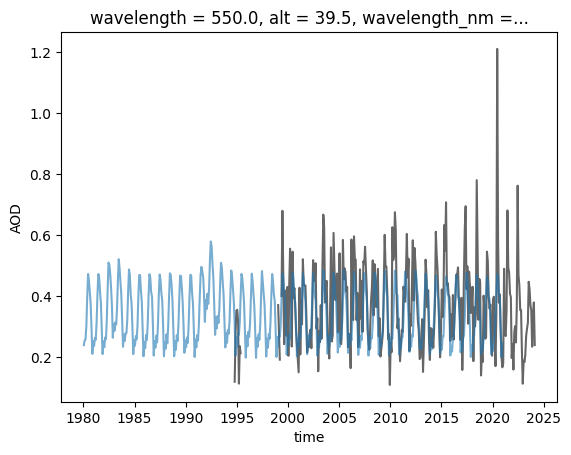

In [57]:
wl = 550 # Wavelength in nm
aeronet_wafr_coll.get_obs_aod()["AOD"].mean(dim="station_name").sel(wavelength_nm=wl).plot(label="AERONET", color="black", alpha=0.6)
aeronet_wafr_coll.calculate_aod(source="cams_clim")["AOD"].mean(dim="station_name").sel(wavelength=wl).plot(label="CAMSClim", alpha=0.6)
aeronet_wafr_coll.calculate_aod(source="cams_free")["AOD"].mean(dim="station_name").sel(wavelength=wl).plot(label="CAMS Free", alpha=0.6)
